# RETO 1: Determinación de la población real del destino

En un destino turístico residencial como Torrevieja, la población empadronada no coincide necesariamente con la población realmente presente en cada momento. Por ello, el objetivo de este reto es **estimar o aproximar la población efectiva y analizar cómo varía a lo largo del tiempo**.

## 1. INTRODUCCIÓN

A continuación, se define el marco teórico sobre la población flotante, las fuentes utilizadas para su aproximación y sus limitaciones.

#### A. Definición de la Población Real o Efectiva

En el análisis demográfico y turístico, es crucial distinguir entre diferentes capas de población:

* **Población Empadronada:** Son las personas inscritas oficialmente en el padrón municipal. Es la cifra estática que usa el Estado para asignar recursos, pero en destinos turísticos suele subestimar la realidad.
* **Población Flotante:** Es el conjunto de personas que, sin estar empadronadas, residen temporalmente en el municipio. Incluye turistas de hotel, turistas de segunda residencia, excursionistas y trabajadores de temporada.
* **Población Real:** Es la suma de la población empadronada presente más la población flotante en un momento dado. Es la cantidad real de personas que consumen recursos y requieren servicios públicos en el destino.

#### B. Indicadores y Variables de Aproximación

Como no es posible realizar un censo diario, se utilizan variables *proxy* (rastros indirectos que deja el consumo humano):

* **Generación de Residuos Sólidos Urbanos (RSU):** Cantidad de basura recogida; es uno de los indicadores tradicionales más fiables.
* **Consumo de Agua Potable y Depuración:** Volumen de agua suministrada a la red o de aguas residuales tratadas. 
* **Consumo de Energía Eléctrica:** Picos de demanda energética residencial.
* **Big Data de Movilidad:** Conteo de dispositivos móviles conectados a las antenas de telefonía del municipio.
* **Plazas de Alojamiento y Ocupación:** Multiplicación de las camas turísticas y segundas residencias por índices de ocupación. 

#### C. Supuestos de Partida

Toda estimación basada en variables *proxy* requiere asumir ciertas hipótesis:

* **Estabilidad del consumo per cápita:** Suponemos que cada individuo genera una cantidad media similar de basura o consume una cantidad de agua predecible al día.
* **Correlación lineal:** Asumimos que las variaciones porcentuales en el consumo (ej. aumento del 50% de basura en agosto) equivalen matemáticamente al aumento de la población efectiva.
* **Homogeneidad tecnológica:** Si utilizamos datos móviles, asumimos que un dispositivo equivale a una persona.

#### D. Nivel de Confianza y Limitaciones

El modelo proporciona una estimación estadística sujeta a las siguientes limitaciones:

* **Estacionalidad del consumo:** Un turista en verano puede consumir más agua (duchas, piscinas) que un residente en invierno. Esto puede sobreestimar la población.
* **Impacto comercial e industrial:** Los consumos y residuos provienen también del sector servicios, cuya actividad se dispara en temporada alta.

Para maximizar el nivel de confianza, es imprescindible cruzar varios indicadores. 

## 2. METODOLOGÍA Y ESTIMACIÓN DE LA POBLACIÓN EFECTIVA

Para comprender la verdadera dimensión demográfica de un destino turístico como Torrevieja, resulta insuficiente basarnos únicamente en los registros oficiales estáticos. El objetivo de este apartado es construir un modelo de datos robusto que nos permita calcular la **Población Efectiva**, es decir, el volumen real de personas que habitan y consumen recursos en el municipio a lo largo del año.

Para abordar este reto y garantizar la reproducibilidad del análisis, documentamos a continuación todo el proceso de preparación y limpieza de datos, estructurando la metodología en tres grandes fases secuenciales:

* **A. Censo de Torrevieja (Población Base):** Analizamos y depuramos los padrones oficiales (INE y Generalitat Valenciana) para establecer la línea base de residentes estables.
* **B. Dispositivos Móviles para la Movilidad (Población Flotante):** Procesamos mediante Big Data millones de rastros de telefonía móvil para cuantificar los flujos reales de visitantes (turismo nacional e internacional) y aislar el efecto de la estacionalidad.
* **C. Cálculo de la Población Real (Integración Final):** Unimos matemáticamente la población estática y la movilidad dinámica para obtener la curva demográfica efectiva del destino.

A continuación, detallamos el tratamiento analítico aplicado a cada una de estas fuentes para resolver el primer reto.

#### A. CENSO DE TORREVIEJA

Para establecer la población empadronada extraemos datos de dos fuentes oficiales:

* **Instituto Nacional de Estadística (INE):** Descargamos el Padrón continuo por municipios, obteniendo el archivo [`censo_1996_2025.csv`](https://www.ine.es/jaxiT3/Tabla.htm?t=2856&L=0) con periodicidad anual. 
* **Portal Estadístic de la Generalitat Valenciana (PEGV):** Extraemos las [Estimaciones de población (PEGV)](https://pegv.gva.es/es/estimaciones-de-poblacion-de-la-comunitat-valenciana), las cuales aportan un valor añadido al ofrecer desagregación semestral (enero y julio). Los datos se han obtenido en tres cortes temporales: `censo_2002_2012_pegv.csv`, `censo_2013_2020_pegv.csv` y `censo_2021_2023_pegv.csv`.

##### A.1. INSTITUTO NACIONAL DE ESTADÍSTICA (INE)

In [20]:
#!pip install pandas matplotlib openpyxl

In [21]:
# ==============================================================================
# IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DE RUTAS
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import os
import locale
from matplotlib.dates import DateFormatter, YearLocator
from pathlib import Path

base_dir = Path.cwd()
ruta_censo_ine = (
    base_dir.parent / "DATASETS" / "RETO 1" /
    "DATASETS ORIGINALES" / "Censo" / "censo_1996_2025_ine.csv"
)
ruta_salida = base_dir.parent / "DATASETS" / "RETO 1" / "DATASETS MODIFICADOS"


# ==============================================================================
# CARGA DE DATOS DEL INE
# ==============================================================================
# Forzamos la lectura del separador de miles para asegurar la correcta interpretación numérica
df_censo_ine = pd.read_csv(ruta_censo_ine, sep=';', encoding='latin1', thousands='.')

Una vez cargados los datos, realizamos un Análisis Exploratorio de Datos (EDA) inicial para comprender la estructura del *dataset*, verificar los tipos de datos de cada columna y comprobar la existencia de registros completamente duplicados.

In [22]:
print("=== PRIMERAS FILAS DEL DATASET ===")
display(df_censo_ine.head())

print("\n=== INFORMACIÓN GENERAL DEL DATASET ===")
# Verificamos tipos de datos y nulos a nivel general
df_censo_ine.info()

# Comprobamos si existen registros duplicados exactos
duplicados = df_censo_ine.duplicated().sum()
print(f"\nNúmero de filas exactamente iguales (duplicadas): {duplicados}\n")

=== PRIMERAS FILAS DEL DATASET ===


,Municipios,Sexo,Periodo,Total
0,03133 Torrevieja,Total,2025,98533.0
1,03133 Torrevieja,Total,2024,94803.0
2,03133 Torrevieja,Total,2023,89290.0
3,03133 Torrevieja,Total,2022,83547.0
4,03133 Torrevieja,Total,2021,82842.0



=== INFORMACIÓN GENERAL DEL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Municipios  90 non-null     str    
 1   Sexo        90 non-null     str    
 2   Periodo     90 non-null     int64  
 3   Total       87 non-null     float64
dtypes: float64(1), int64(1), str(2)
memory usage: 2.9 KB

Número de filas exactamente iguales (duplicadas): 0



A simple vista, identificamos que la columna del total de población contiene valores vacíos. Para entender el contexto de estos datos faltantes, primero revisamos los valores únicos de cada columna y, posteriormente, aislamos las filas específicas que no tienen el campo `Total` relleno.

In [23]:
print("=== CONTEO DE VALORES NULOS POR COLUMNA ===")
print(df_censo_ine.isnull().sum())

print("\n=== ANÁLISIS DE VALORES ÚNICOS POR COLUMNA ===")
# Iteramos sobre las columnas para entender la cardinalidad
for col in df_censo_ine.columns:
    num_unicos = df_censo_ine[col].nunique()
    print(f"Columna '{col}': {num_unicos} valores únicos.")
    # Mostramos los valores si la variable es categórica
    if num_unicos < 50:
        print(f"   Valores: {df_censo_ine[col].unique()}")

# Aislamos las filas donde la población es nula
filas_nulas = df_censo_ine[df_censo_ine['Total'].isnull()]
print("\n=== FILAS CON EL TOTAL SIN RELLENAR ===")
display(filas_nulas)

=== CONTEO DE VALORES NULOS POR COLUMNA ===
Municipios    0
Sexo          0
Periodo       0
Total         3
dtype: int64

=== ANÁLISIS DE VALORES ÚNICOS POR COLUMNA ===
Columna 'Municipios': 1 valores únicos.
   Valores: <StringArray>
['03133 Torrevieja']
Length: 1, dtype: str
Columna 'Sexo': 3 valores únicos.
   Valores: <StringArray>
['Total', 'Hombres', 'Mujeres']
Length: 3, dtype: str
Columna 'Periodo': 30 valores únicos.
   Valores: [2025 2024 2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012
 2011 2010 2009 2008 2007 2006 2005 2004 2003 2002 2001 2000 1999 1998
 1997 1996]
Columna 'Total': 87 valores únicos.

=== FILAS CON EL TOTAL SIN RELLENAR ===


,Municipios,Sexo,Periodo,Total
28,03133 Torrevieja,Total,1997,NaN
58,03133 Torrevieja,Hombres,1997,NaN
88,03133 Torrevieja,Mujeres,1997,NaN


Al realizar esta exploración inicial sobre el *dataset*, extraemos que:

* Los datos corresponden en exclusiva al municipio de Torrevieja (código INE `03133 Torrevieja`), lo que nos garantiza que no hay ruido o registros mezclados de otras localidades.
* El registro abarca una serie histórica ininterrumpida de 30 años, comenzando en 1996 y llegando hasta 2025 (columna `Periodo`).
* La información poblacional se encuentra dividida en tres categorías dentro de la variable `Sexo`: 'Total', 'Hombres' y 'Mujeres'.
* El *dataset* debería contener 90 registros exactos. Sin embargo, el conteo inicial revela la existencia de 3 valores vacíos (`NaN`) en la columna `Total`.

Al inspeccionar estas filas nulas, detectamos que el año 1997 no tiene datos de padrón registrados para ninguna de las tres categorías de sexo.

Para solucionar esta carencia temporal sin distorsionar la tendencia de los datos, aplicamos una imputación mediante interpolación lineal, calculando matemáticamente los valores faltantes utilizando como anclaje los años adyacentes (1996 y 1998).

In [24]:
# ==============================================================================
# LIMPIEZA DE DATOS E IMPUTACIÓN DE VALORES (INE)
# ==============================================================================
# Ordenamos el dataset cronológicamente y por sexo para que la interpolación sea precisa
df_censo_ine = df_censo_ine.sort_values(by=['Sexo', 'Periodo']).reset_index(drop=True)

# Aplicamos interpolación lineal agrupada por categoría
df_censo_ine['Total'] = df_censo_ine.groupby('Sexo')['Total'].transform(lambda x: x.interpolate(method='linear'))

# Redondeamos los valores generados y los forzamos a entero
df_censo_ine['Total'] = df_censo_ine['Total'].round().astype(int)

print("\n=== COMPROBACIÓN POST-LIMPIEZA ===")
print("Nulos restantes en 'Total' tras la interpolación:", df_censo_ine['Total'].isnull().sum())


=== COMPROBACIÓN POST-LIMPIEZA ===
Nulos restantes en 'Total' tras la interpolación: 0


Con el *dataset* limpio y sin valores ausentes, procedemos a exportarlo a nuestra carpeta de datos modificados. 

In [25]:
# ==============================================================================
# EXPORTACIÓN DEL DATASET LIMPIO (INE)
# ==============================================================================
# Aseguramos que el directorio de salida exista
os.makedirs(ruta_salida, exist_ok=True)

# Guardamos en formato CSV asegurando la codificación correcta
ruta_archivo_limpio = os.path.join(ruta_salida, 'censo_ine_limpio.csv')
df_censo_ine.to_csv(ruta_archivo_limpio, index=False, sep=';', encoding='utf-8-sig')

print(f"\nArchivo limpio guardado correctamente")


Archivo limpio guardado correctamente


Para concluir con la preparación de esta primera fuente, visualizamos la evolución del padrón oficial de Torrevieja. Esto nos servirá como línea base (población empadronada) contra la cual compararemos más adelante las estimaciones de población flotante.

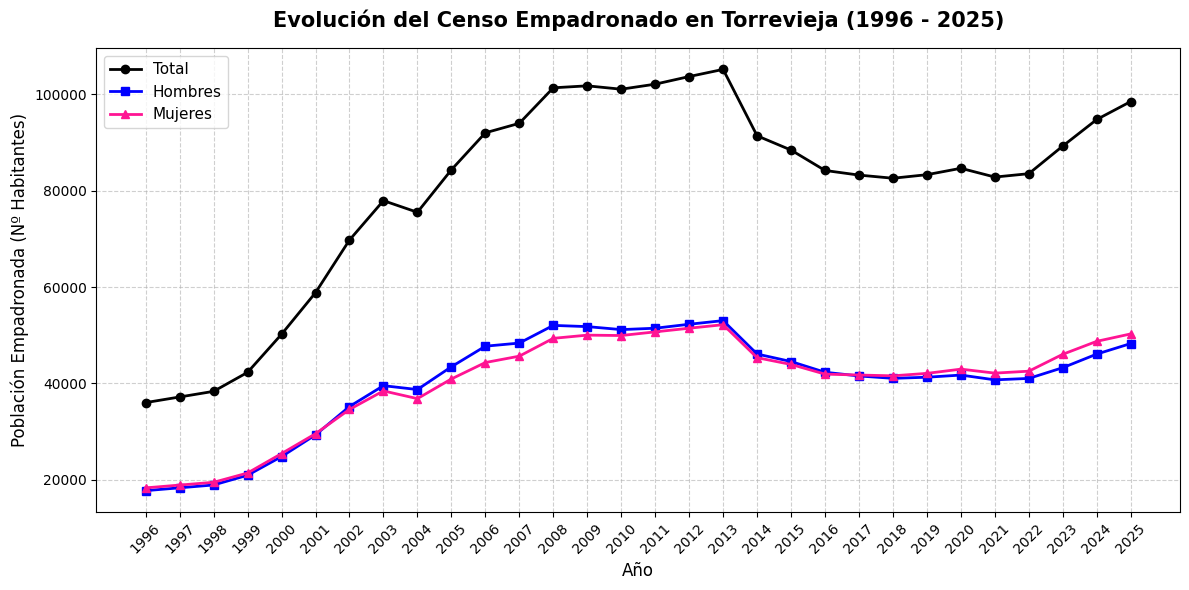

In [26]:
# ==============================================================================
# VISUALIZACIÓN DE LA EVOLUCIÓN POBLACIONAL (INE)
# ==============================================================================
# Separamos los dataframes por categoría para facilitar el trazado
df_total = df_censo_ine[df_censo_ine['Sexo'] == 'Total']
df_hombres = df_censo_ine[df_censo_ine['Sexo'] == 'Hombres']
df_mujeres = df_censo_ine[df_censo_ine['Sexo'] == 'Mujeres']

plt.figure(figsize=(12, 6))

# Trazamos las series temporales
plt.plot(df_total['Periodo'], df_total['Total'], color='black', label='Total', marker='o', linewidth=2)
plt.plot(df_hombres['Periodo'], df_hombres['Total'], color='blue', label='Hombres', marker='s', linewidth=2)
plt.plot(df_mujeres['Periodo'], df_mujeres['Total'], color='deeppink', label='Mujeres', marker='^', linewidth=2)

plt.title('Evolución del Censo Empadronado en Torrevieja (1996 - 2025)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Población Empadronada (Nº Habitantes)', fontsize=12)

# Ajustamos las etiquetas del eje X para mejor lectura
plt.xticks(df_total['Periodo'], rotation=45)

plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

##### A.2. PORTAL ESTADÍSTIC DE LA GENERALITAT VALENCIANA (PEGV)

Una vez consolidado el *dataset* del INE, pasamos a estudiar la segunda fuente: el Portal Estadístic de la Generalitat Valenciana (PEGV). Esta fuente es especialmente valiosa porque nos ofrece cortes semestrales (enero y julio), lo que resulta muy útil para analizar la estacionalidad en un destino turístico.

Al descargar la información, observamos que los datos históricos no se encuentran en un único archivo, sino divididos en tres cortes temporales: 2002-2012, 2013-2020 y 2021-2023. El primer paso es cargar estos tres *datasets* para proceder a su análisis.

In [27]:
# ==============================================================================
# LECTURA DE LOS 3 ARCHIVOS DE LA PEGV
# ==============================================================================
# Utilizamos el separador y la codificación adecuada según el origen de los datos
ruta_pegv_1 = (
    base_dir.parent / "DATASETS" / "RETO 1" /
    "DATASETS ORIGINALES" / "Censo" / "censo_2002_2012_pegv.csv")
ruta_pegv_2 = (
    base_dir.parent / "DATASETS" / "RETO 1" /
    "DATASETS ORIGINALES" / "Censo" / "censo_2013_2020_pegv.csv")
ruta_pegv_3 = (
    base_dir.parent / "DATASETS" / "RETO 1" /
    "DATASETS ORIGINALES" / "Censo" / "censo_2021_2023_pegv.csv")

df_pegv_1 = pd.read_csv(ruta_pegv_1, sep=';', encoding='latin1')
df_pegv_2 = pd.read_csv(ruta_pegv_2, sep=';', encoding='latin1')
df_pegv_3 = pd.read_csv(ruta_pegv_3, sep=';', encoding='latin1')

# ==============================================================================
# ANÁLISIS EXPLORATORIO INDIVIDUAL
# ==============================================================================
def hacer_eda_basico(df, nombre_df):
    print(f"\n{'='*50}")
    print(f" EDA DEL DATASET: {nombre_df}")
    print(f"{'='*50}")
    print("\nNombre de las columnas:")
    print(df.columns.tolist())
    print("\nTipos de datos y nulos:")
    df.info()
    print("\nPrimeras 3 filas:")
    display(df.head(3))

# Ejecutamos la función de exploración para cada archivo
hacer_eda_basico(df_pegv_1, "CENSO 2002-2012")
hacer_eda_basico(df_pegv_2, "CENSO 2013-2020")
hacer_eda_basico(df_pegv_3, "CENSO 2021-2023")


 EDA DEL DATASET: CENSO 2002-2012

Nombre de las columnas:
['Periodo', 'Municipios', 'Sexo', 'Edad', 'Valor']

Tipos de datos y nulos:
<class 'pandas.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Periodo     660 non-null    str  
 1   Municipios  660 non-null    str  
 2   Sexo        660 non-null    str  
 3   Edad        660 non-null    str  
 4   Valor       660 non-null    int64
dtypes: int64(1), str(4)
memory usage: 25.9 KB

Primeras 3 filas:


,Periodo,Municipios,Sexo,Edad,Valor
0,1 de enero de 2002,03133 - Torrevieja,Ambos sexos,De 0 a 4 años,2363
1,1 de enero de 2002,03133 - Torrevieja,Ambos sexos,De 10 a 14 años,2502
2,1 de enero de 2002,03133 - Torrevieja,Ambos sexos,De 15 a 19 años,2595



 EDA DEL DATASET: CENSO 2013-2020

Nombre de las columnas:
['Periodo', 'Municipios', 'Sexo', 'Edad', 'Valor']

Tipos de datos y nulos:
<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Periodo     1197 non-null   str  
 1   Municipios  1197 non-null   str  
 2   Sexo        1197 non-null   str  
 3   Edad        1197 non-null   str  
 4   Valor       1197 non-null   int64
dtypes: int64(1), str(4)
memory usage: 46.9 KB

Primeras 3 filas:


,Periodo,Municipios,Sexo,Edad,Valor
0,1 de enero de 2012,03133 - Torrevieja,Ambos sexos,95 y más años,82
1,1 de enero de 2012,03133 - Torrevieja,Ambos sexos,De 0 a 4 años,3858
2,1 de enero de 2012,03133 - Torrevieja,Ambos sexos,De 10 a 14 años,3665



 EDA DEL DATASET: CENSO 2021-2023

Nombre de las columnas:
['Periodo', 'Municipios', 'Sexo', 'Edad (grupos quinquenales)', 'Valor']

Tipos de datos y nulos:
<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Periodo                     420 non-null    str  
 1   Municipios                  420 non-null    str  
 2   Sexo                        420 non-null    str  
 3   Edad (grupos quinquenales)  420 non-null    str  
 4   Valor                       420 non-null    int64
dtypes: int64(1), str(4)
memory usage: 16.5 KB

Primeras 3 filas:


,Periodo,Municipios,Sexo,Edad (grupos quinquenales),Valor
0,1 de enero de 2021,03133 - Torrevieja,Ambos sexos,De 0 a 4 años,3158
1,1 de enero de 2021,03133 - Torrevieja,Ambos sexos,De 10 a 14 años,4353
2,1 de enero de 2021,03133 - Torrevieja,Ambos sexos,De 15 a 19 años,3956


Al analizar la salida del Análisis Exploratorio de Datos (EDA) de los tres archivos, identificamos la estructura de los *datasets* y un problema clave de formato que nos impide unirlos directamente:

* Los tres documentos comparten estructura, donde cada fila representa una combinación de `Periodo`, `Municipios`, `Sexo`, una franja de edad y su `Valor` (número de habitantes). No presentan valores nulos.
* Los dos primeros *datasets* (2002-2012 y 2013-2020) nombran a la columna de tramos de edad simplemente como `Edad`. Sin embargo, el tercer *dataset* (2021-2023) la nombra como `Edad (grupos quinquenales)`. 

Para poder integrar los tres archivos, el primer paso consiste en normalizar los nombres de las columnas. Igualamos los nombres antes de proceder a la unión.

Una vez homogeneizados, concatenamos los marcos de datos en una única estructura para visualizar el estado inicial de la información y comprobar cómo se comporta la serie temporal.

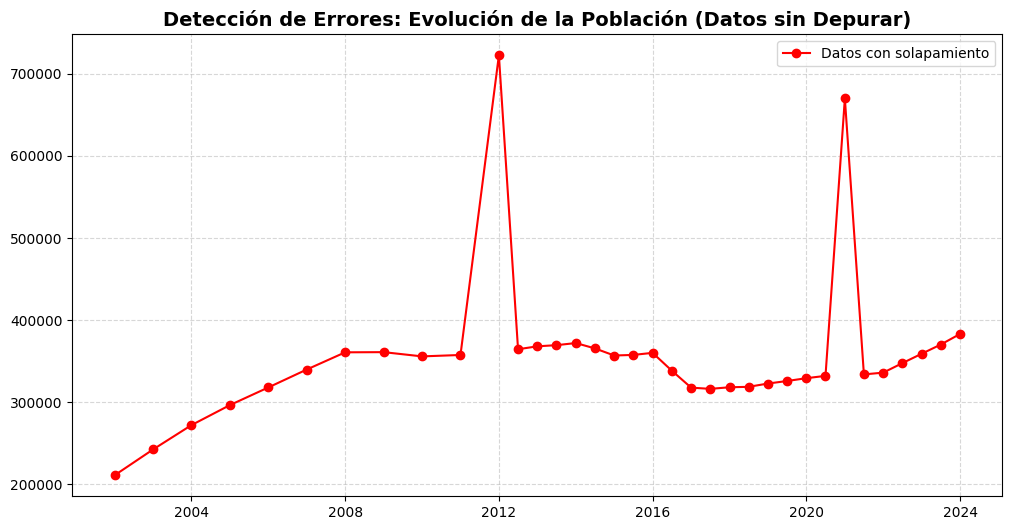

In [28]:
# ==============================================================================
# HOMOGENEIZACIÓN Y DETECCIÓN DEL ERROR
# ==============================================================================
# Homogeneizamos los nombres de las columnas para permitir la unión
if 'Edad (grupos quinquenales)' in df_pegv_3.columns:
    df_pegv_3 = df_pegv_3.rename(columns={'Edad (grupos quinquenales)': 'Edad'})

# Unimos los tres archivos en un único DataFrame sin limpiar
df_pegv_sucio = pd.concat([df_pegv_1, df_pegv_2, df_pegv_3], ignore_index=True)

# Preparamos las fechas y agrupamos para mostrar el error inicial
locale.setlocale(locale.LC_TIME, "es_ES.UTF-8")
df_pegv_sucio['Periodo_dt'] = pd.to_datetime(df_pegv_sucio['Periodo'], format='%d de %B de %Y')
df_error = df_pegv_sucio.groupby(['Periodo_dt'])['Valor'].sum().reset_index()

# Graficamos el estado inicial para identificar anomalías
plt.figure(figsize=(12, 6))
plt.plot(df_error['Periodo_dt'], df_error['Valor'], marker='o', color='red', label='Datos con solapamiento')
plt.title('Detección de Errores: Evolución de la Población (Datos sin Depurar)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

Durante la integración de los datos y al observar la gráfica anterior, detectamos un problema crítico: los archivos descargados de la Generalitat se solapaban en los años de corte temporal (2012 y 2021). Al realizar la concatenación directa, estos años se duplicaron. Si sumáramos los habitantes directamente en este estado, se generarían *outliers* artificiales, mostrando que Torrevieja duplicaba repentinamente su población.

Para solucionar esto y obtener un *dataset* final (`censo_pegv_unificado.csv`), aplicamos las siguientes transformaciones:

* Eliminamos los duplicados para suprimir el efecto del solapamiento.
* Agrupamos los datos y calculamos el total sumando los habitantes de todos los tramos de edad.
* Normalizamos las categorías, renombrando la etiqueta `Ambos sexos` a `Total` para mantener la consistencia con el formato del INE.

In [29]:
# ==============================================================================
# LIMPIEZA Y TRANSFORMACIÓN FINAL DE LA PEGV (MANTENIENDO ENERO Y JULIO)
# ==============================================================================
# Eliminamos los registros duplicados especificando las columnas clave
df_pegv_limpio = df_pegv_sucio.drop_duplicates(subset=['Periodo', 'Municipios', 'Sexo', 'Edad'], keep='last')

# Agrupamos y calculamos el total sumando las franjas de edad
df_edades = df_pegv_limpio[df_pegv_limpio['Edad'] != 'Total']
df_unificado = df_edades.groupby(['Periodo', 'Sexo'])['Valor'].sum().reset_index()

# Normalizamos la nomenclatura para que coincida con el INE
df_unificado['Sexo'] = df_unificado['Sexo'].replace({'Ambos sexos': 'Total'})

# Guardamos el dataset final depurado con todos los semestres incluidos
ruta_pegv_unificado = os.path.join(ruta_salida, 'censo_pegv_unificado.csv')
df_unificado.to_csv(ruta_pegv_unificado, index=False, sep=';', encoding='utf-8-sig')

print("Archivo PEGV completo depurado y guardado con éxito.")

Archivo PEGV completo depurado y guardado con éxito.


Una vez subsanados los errores de solapamiento y normalizadas las categorías, procedemos a representar de nuevo la evolución de la población total. Como se observa a continuación, la serie histórica ahora presenta una tendencia lógica y coherente, habiendo eliminado los picos irreales.

Como nuestra intención en esta fase inicial es establecer la población residente y compararla posteriormente con el padrón del INE (que se publica con fecha de corte de 1 de enero), filtramos momentáneamente el *dataset* para graficar únicamente las mediciones de enero, aislando así a la población estable de la estacionalidad del verano.

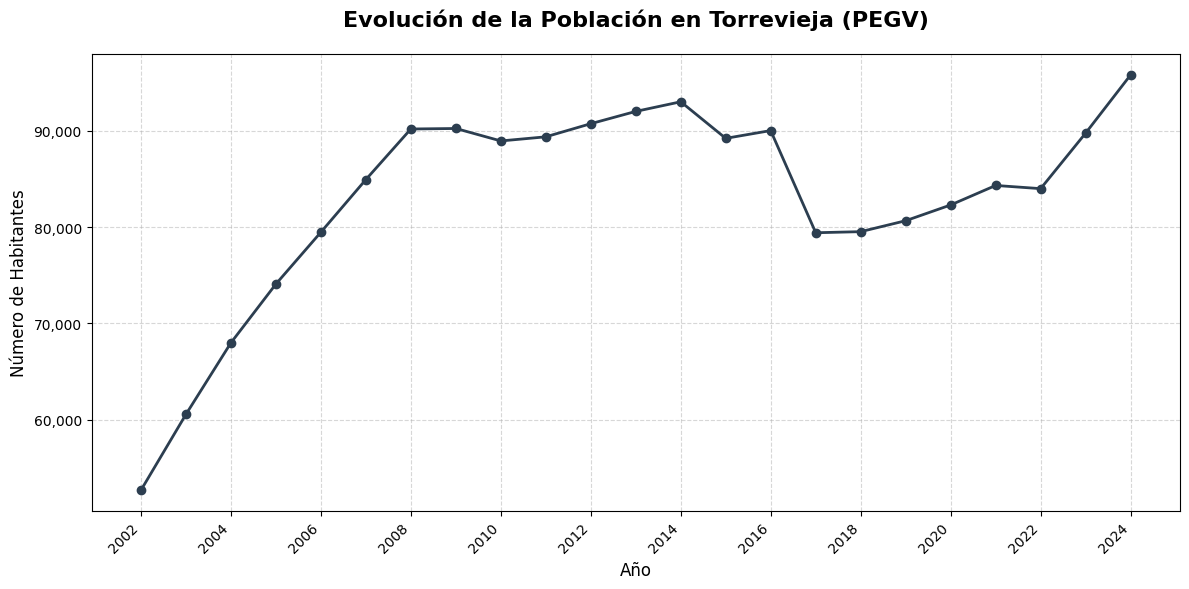

In [30]:
# ==============================================================================
# GRÁFICA DE LA POBLACIÓN TOTAL
# ==============================================================================
# Filtramos para conservar exclusivamente la foto demográfica de enero en esta gráfica
df_enero_grafica = df_unificado[df_unificado['Periodo'].str.contains('1 de enero', case=False, na=False)].copy()

# Transformamos las fechas para la representación
df_enero_grafica['Periodo_dt'] = pd.to_datetime(df_enero_grafica['Periodo'], format='%d de %B de %Y')
df_enero_grafica = df_enero_grafica.sort_values('Periodo_dt')

# Filtramos la población total
df_final = df_enero_grafica[df_enero_grafica['Sexo'] == 'Total']

plt.figure(figsize=(12, 6))

# Dibujamos la evolución
plt.plot(df_final['Periodo_dt'], df_final['Valor'], marker='o', linestyle='-', color='#2c3e50', linewidth=2)

# Ajustamos el formato de los ejes
ax = plt.gca()
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title('Evolución de la Población en Torrevieja (PEGV)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Habitantes', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Para tener una visión más detallada de este censo de la Generalitat, representamos también la evolución diferenciando por sexo, manteniendo el filtro del 1 de enero para asegurar la coherencia visual con la gráfica del INE.

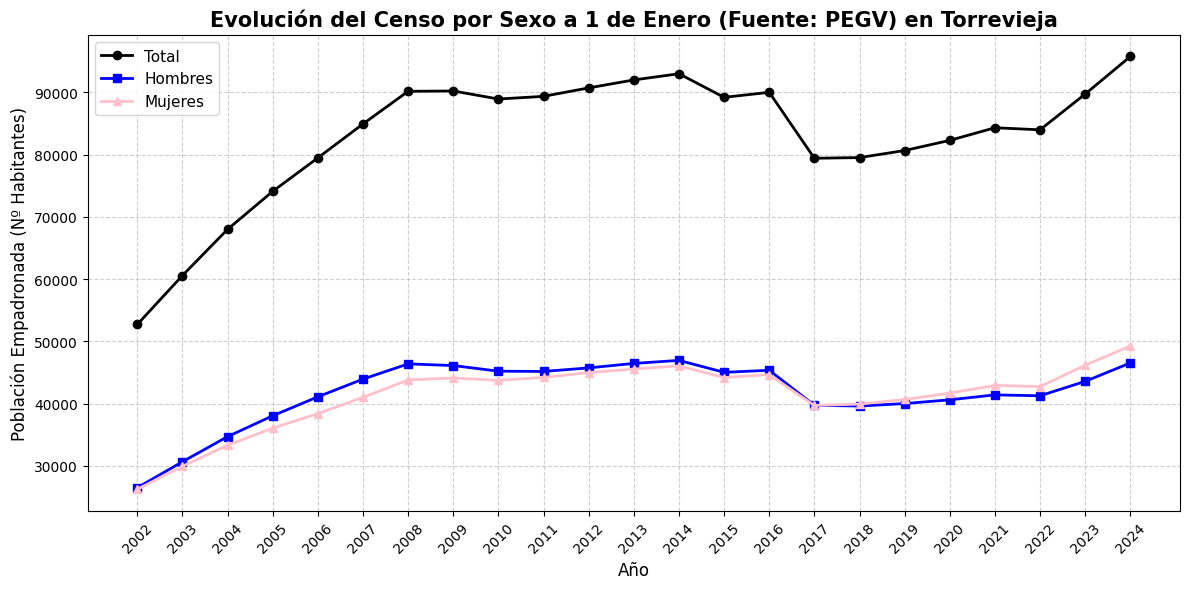

In [31]:
# ==============================================================================
# GRÁFICA SEGMENTADA POR SEXO (PEGV - ENERO)
# ==============================================================================
# Extraemos el año numérico para el eje X
df_enero_grafica['Año'] = df_enero_grafica['Periodo_dt'].dt.year

# Dividimos en DataFrames separados por categoría
df_total = df_enero_grafica[df_enero_grafica['Sexo'] == 'Total']
df_hombres = df_enero_grafica[df_enero_grafica['Sexo'] == 'Hombres']
df_mujeres = df_enero_grafica[df_enero_grafica['Sexo'] == 'Mujeres']

plt.figure(figsize=(12, 6))

# Trazamos las líneas con sus respectivos colores
plt.plot(df_total['Año'], df_total['Valor'], color='black', label='Total', marker='o', linewidth=2)
plt.plot(df_hombres['Año'], df_hombres['Valor'], color='blue', label='Hombres', marker='s', linewidth=2)
plt.plot(df_mujeres['Año'], df_mujeres['Valor'], color='pink', label='Mujeres', marker='^', linewidth=2)

plt.title('Evolución del Censo por Sexo a 1 de Enero (Fuente: PEGV) en Torrevieja', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Población Empadronada (Nº Habitantes)', fontsize=12)

# Configuramos el eje X para mostrar todos los años inclinados
plt.xticks(df_total['Año'], rotation=45)

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


##### A.3. COMPARATIVA FINAL: INE VS PEGV

Tras procesar y homogenizar las dos fuentes principales de datos poblacionales, realizamos un cruce final para comparar las cifras del censo oficial del Estado (INE) con las estimaciones autonómicas (PEGV). 

Es imprescindible aplicar un filtro para utilizar únicamente los registros de la PEGV fechados a `1 de enero`. De esta forma, garantizamos que la comparativa sea precisa y equitativa. 

=== TABLA DE DIFERENCIAS (INE vs PEGV - A 1 DE ENERO) ===
 Año  Total_INE  Total_PEGV  Diferencia (INE - PEGV)
2002      69763       52712                    17051
2003      77943       60572                    17371
2004      75530       67988                     7542
2005      84348       74095                    10253
2006      92034       79468                    12566
2007      94006       84921                     9085
2008     101381       90164                    11217
2009     101792       90216                    11576
2010     101091       88925                    12166
2011     102136       89353                    12783
2012     103720       90713                    13007
2013     105205       91990                    13215
2014      91415       92987                    -1572
2015      88447       89194                     -747
2016      84213       90001                    -5788
2017      83252       79405                     3847
2018      82599       79517              

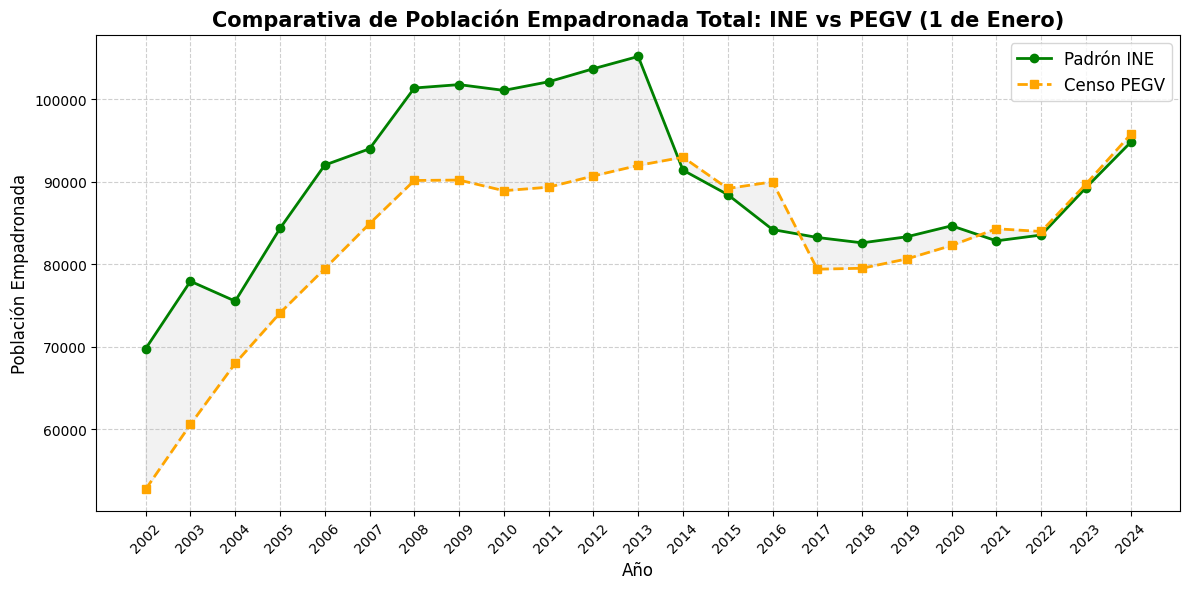

In [32]:
# ==============================================================================
# PREPARACIÓN Y CRUCE DE AMBAS FUENTES
# ==============================================================================
# Cargamos los archivos finales (el de la PEGV incluye enero y julio)
df_ine = pd.read_csv(ruta_archivo_limpio, sep=';', encoding='utf-8-sig')
df_pegv = pd.read_csv(ruta_pegv_unificado, sep=';', encoding='utf-8-sig')

# Preparamos el dataset del INE
if 'Periodo' in df_ine.columns:
    df_ine = df_ine.rename(columns={'Periodo': 'Año'})
df_ine_total = df_ine[df_ine['Sexo'] == 'Total'][['Año', 'Total']].rename(columns={'Total': 'Total_INE'})

# Preparamos el dataset de la PEGV
# Filtramos explícitamente para aislar la foto demográfica de enero antes de cruzar
df_pegv_enero = df_pegv[df_pegv['Periodo'].str.contains('1 de enero', case=False, na=False)].copy()

# Extraemos el año numérico
df_pegv_enero['Año'] = df_pegv_enero['Periodo'].str.extract(r'(\d{4})').astype(int)
df_pegv_total = df_pegv_enero[df_pegv_enero['Sexo'] == 'Total'][['Año', 'Valor']].rename(columns={'Valor': 'Total_PEGV'})

# Realizamos la unión de las dos tablas basándonos en el año (inner join)
df_comparativa = pd.merge(df_ine_total, df_pegv_total, on='Año', how='inner')

# Calculamos la diferencia matemática
df_comparativa['Diferencia (INE - PEGV)'] = df_comparativa['Total_INE'] - df_comparativa['Total_PEGV']

print("=== TABLA DE DIFERENCIAS (INE vs PEGV - A 1 DE ENERO) ===")
print(df_comparativa.to_string(index=False))

# ==============================================================================
# GRÁFICA COMPARATIVA
# ==============================================================================
plt.figure(figsize=(12, 6))

# Trazamos ambas series temporales
plt.plot(df_comparativa['Año'], df_comparativa['Total_INE'], label='Padrón INE', marker='o', color='green', linewidth=2)
plt.plot(df_comparativa['Año'], df_comparativa['Total_PEGV'], label='Censo PEGV', marker='s', color='orange', linewidth=2, linestyle='--')

# Añadimos un sombreado entre las líneas para destacar visualmente la diferencia
plt.fill_between(df_comparativa['Año'], df_comparativa['Total_INE'], df_comparativa['Total_PEGV'], color='gray', alpha=0.1)

# Estilos y diseño de la gráfica
plt.title('Comparativa de Población Empadronada Total: INE vs PEGV (1 de Enero)', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Población Empadronada', fontsize=12)
plt.xticks(df_comparativa['Año'], rotation=45)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

Como podemos observar, se identifican discrepacias entre los datos recogidos por el INE y los del PEGV. De esta gráfica podemos extraer las siguientes conclusiones: 

* Del 2002 al 2013, observamos una diferencia enorme entre ambas fuentes. El INE registraba un excedente de entre 9.000 y 17.000 habitantes respecto a la PEGV. Esta discrepancia no era real, sino administrativa: muchos residentes extranjeros se empadronaban al llegar, pero no se daban de baja al regresar a sus países o al cambiar de residencia.
* Entre 2013 y 2014, la línea del INE pierde más de 13.000 habitantes en un solo año; esto coincide con la normativa estatal que obligó a los Ayuntamientos a limpiar y actualizar sus padrones, eliminando a los extranjeros que no habían renovado su residencia. La PEGV, al basarse en estimaciones apenas sufrió variación demostrando ser una fuente mucho más estable frente al ruido administrativo.
* Tras la regularización de 2014, ambas series temporales convergen de manera casi idéntica. Las diferencias estadísticas se vuelven mínimas, consolidando una base de residentes estable que oscila entre los 80.000 y los 95.000 habitantes en la última década.

Esta comparativa valida la robustez de los datos de la **PEGV**. Al haber demostrado ser históricamente más inmune a los errores burocráticos del padrón y, además, ofrecernos una granularidad semestral (enero y julio), decidimos establecer el *dataset* unificado de la PEGV como nuestra Población Base. 

En el siguiente paso incorporaremos los indicadores *proxy* (residuos sólidos, consumo de agua, etc.) para empezar a modelar la Población Flotante y calcular, finalmente, la **Población Efectiva** del destino.

#### B. DISPOSITIVOS MÓVILES PARA LA MOVILIDAD (INE)

Para cuantificar de manera empírica la Población Flotante (turistas, visitantes y residentes no empadronados), utilizamos la [estadística experimental del INE basada en la telefonía móvil](https://www.ine.es/experimental/turismo_moviles/experimental_turismo_moviles.htm). Esta fuente analiza el posicionamiento de las tarjetas SIM conectadas a las antenas del municipio, ofreciendo un conteo real de personas presentes.

Esta metodología nos permite superar las limitaciones del padrón, capturando tres flujos de movilidad esenciales entre 2019 y 2026:

* **Turismo Receptor:** Dispositivos móviles extranjeros (*roaming*) detectados en Torrevieja.
* **Turismo Interno Interprovincial:** Dispositivos móviles españoles (de otras provincias) detectados en el municipio.
* **Turismo Emisor:** Residentes en Torrevieja que viajan a otros destinos (necesarios para restar a los empadronados que están ausentes temporalmente).

Los datos brutos (*raw data*) presentan los siguientes desafíos: 

* La información se distribuye en decenas de libros de Excel divididos por año y tipo de flujo.
* Cada archivo contiene múltiples hojas (una por mes), lo que impide una carga directa convencional.
* Los archivos contienen la matriz de movilidad de todos los municipios de España, sumando millones de filas. 

Para extraer únicamente la movilidad de Torrevieja, diseñamos un algoritmo automatizado. Debido al ingente volumen de datos, desarrollamos una función que realiza una lectura profunda de los archivos. El algoritmo recorre cada libro de Excel, detecta automáticamente los meses en las hojas y aplica un filtro espacial. 

De esta manera, descartamos la gran mayoría del ruido geográfico de España y nos quedamos exclusivamente con los registros donde Torrevieja actúa como origen o destino.

In [33]:
# ==============================================================================
# IMPORTACIÓN DE LIBRERÍAS, RUTAS Y EXTRACCIÓN MASIVA
# ==============================================================================
import pandas as pd
import os
import warnings
import re

# Desactivamos avisos estéticos relacionados con la lectura de formatos Excel
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# Definimos las rutas de origen y destino
ruta_base = base_dir.parent / "DATASETS" / "RETO 1"

RUTA_RECEPTOR = ruta_base / "DATASETS ORIGINALES" / "Turismo receptor - teléfonos móviles"
RUTA_EMISOR   = ruta_base / "DATASETS ORIGINALES" / "Turismo emisor - teléfonos móviles"
RUTA_INTERNO  = ruta_base / "DATASETS ORIGINALES" / "Turismo interno interprovincial - teléfonos móviles"
RUTA_SALIDA   = ruta_base / "DATASETS MODIFICADOS"

# Función para procesar y filtrar la matriz de movilidad nacional
def procesar_telefonia_movil(ruta_carpeta, tipo):
    print(f"\n{'='*50}")
    print(f" PROCESAMOS DATOS: TURISMO {tipo.upper()}")
    print(f"{'='*50}")
    
    dataframes = []
    
    if not os.path.exists(ruta_carpeta):
        print(f"ERROR: No se encuentra la carpeta {ruta_carpeta}")
        return None

    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith(".xlsx"):
            ruta_archivo = os.path.join(ruta_carpeta, archivo)
            print(f"Leyendo archivo: {archivo}")
            
            match_ano = re.search(r'20\d{2}', archivo)
            año = int(match_ano.group()) if match_ano else None
            
            try:
                hojas = pd.read_excel(ruta_archivo, sheet_name=None)
            except Exception as e:
                print(f"Error al leer {archivo}: {e}")
                continue

            for nombre_hoja, df in hojas.items():
                df = df.copy()
                df["año"] = año
                df["mes_hoja"] = nombre_hoja
                df.columns = df.columns.str.lower().str.strip()

                if tipo == "receptor":
                    df_filtrado = df[df["mun_dest"] == "Torrevieja"]
                elif tipo == "emisor":
                    df_filtrado = df[df["mun_orig"] == "Torrevieja"]
                elif tipo == "interno":
                    df_filtrado = df[df["dest"] == "Torrevieja"]
                
                if not df_filtrado.empty:
                    dataframes.append(df_filtrado)

    if dataframes:
        df_final = pd.concat(dataframes, ignore_index=True)
        df_final.columns = df_final.columns.str.lower().str.strip().str.replace(" ", "_")
        return df_final
    else:
        return None

# Ejecutamos el procesamiento masivo
df_receptor = procesar_telefonia_movil(RUTA_RECEPTOR, "receptor")
df_emisor   = procesar_telefonia_movil(RUTA_EMISOR, "emisor")
df_interno  = procesar_telefonia_movil(RUTA_INTERNO, "interno")

# Guardamos los datasets consolidados
if not os.path.exists(RUTA_SALIDA):
    os.makedirs(RUTA_SALIDA)

def guardar_dataset(df, nombre_archivo):
    if df is not None and not df.empty:
        ruta_completa = os.path.join(RUTA_SALIDA, nombre_archivo)
        df.to_csv(ruta_completa, index=False, sep=';', encoding='utf-8-sig')
        print(f"Exportamos con éxito: {nombre_archivo}")

print("\nGuardando los datos limpios en la carpeta de modificaciones...")
guardar_dataset(df_receptor, "receptor_torrevieja_limpio.csv")
guardar_dataset(df_emisor, "emisor_torrevieja_limpio.csv")
guardar_dataset(df_interno, "interno_torrevieja_limpio.csv")


 PROCESAMOS DATOS: TURISMO RECEPTOR
Leyendo archivo: exp_tmov_receptor_mun_2019.xlsx
Leyendo archivo: exp_tmov_receptor_mun_2020.xlsx
Leyendo archivo: exp_tmov_receptor_mun_2021.xlsx
Leyendo archivo: exp_tmov_receptor_mun_2022.xlsx
Leyendo archivo: exp_tmov_receptor_mun_2023.xlsx
Leyendo archivo: exp_tmov_receptor_mun_2024.xlsx
Leyendo archivo: exp_tmov_receptor_mun_2025.xlsx

 PROCESAMOS DATOS: TURISMO EMISOR
Leyendo archivo: exp_tmov_emisor_mun_2019.xlsx
Leyendo archivo: exp_tmov_emisor_mun_2020.xlsx
Leyendo archivo: exp_tmov_emisor_mun_2021.xlsx
Leyendo archivo: exp_tmov_emisor_mun_2022.xlsx
Leyendo archivo: exp_tmov_emisor_mun_2023.xlsx
Leyendo archivo: exp_tmov_emisor_mun_2024.xlsx
Leyendo archivo: exp_tmov_emisor_mun_2025.xlsx
Leyendo archivo: exp_tmov_emisor_mun_2026.xlsx

 PROCESAMOS DATOS: TURISMO INTERNO
ERROR: No se encuentra la carpeta c:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINAL

Una vez finalizado el proceso de extracción y filtrado masivo, y antes de integrar estos datos en nuestro modelo final de Población Efectiva, realizamos un Análisis Exploratorio de Datos (EDA). El objetivo de esta fase es comprender la estructura interna de los archivos limpios y asegurar que el filtrado ha conservado correctamente la información espacial y temporal.

Para ello, además de comprobar las dimensiones y visualizar los primeros registros, analizamos los valores únicos de cada columna. En esta inspección excluimos deliberadamente las métricas numéricas de volumen (turistas o viajeros), ya que varían constantemente y no aportan valor a la hora de entender la estructura del *dataset*.

In [34]:
# ==============================================================================
# EXPLORACIÓN DE LOS DATASETS DE MOVILIDAD
# ==============================================================================
# Cargamos los archivos recién guardados
df_receptor = pd.read_csv(os.path.join(RUTA_SALIDA, "receptor_torrevieja_limpio.csv"), sep=';', encoding='utf-8-sig')
df_interno = pd.read_csv(os.path.join(RUTA_SALIDA, "interno_torrevieja_limpio.csv"), sep=';', encoding='utf-8-sig')
df_emisor = pd.read_csv(os.path.join(RUTA_SALIDA, "emisor_torrevieja_limpio.csv"), sep=';', encoding='utf-8-sig')

def explorar_dataset_movilidad(df, nombre):
    print(f"\n{'='*50}")
    print(f" ANÁLISIS EXPLORATORIO: {nombre.upper()}")
    print(f"{'='*50}")
    print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas")
    print("Columnas disponibles:", df.columns.tolist())
    
    print("\nValores únicos por columna (excluyendo métricas de volumen):")
    for col in df.columns:
        if not any(palabra in col.lower() for palabra in ['viajero', 'persona', 'turista', 'pernocta', 'valor']):
            num_unicos = df[col].nunique()
            print(f" - '{col}': {num_unicos} valores únicos")
            if num_unicos < 30:
                print(f"    Detalle: {df[col].unique()}")

explorar_dataset_movilidad(df_receptor, "Turismo Receptor (Extranjero)")
explorar_dataset_movilidad(df_interno, "Turismo Interno (Nacional)")
explorar_dataset_movilidad(df_emisor, "Turismo Emisor (Residentes viajando)")

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\Usuario\\Documents\\MASTER EN CIENCIA DE DATOS UA\\MINERIA DE DATOS\\TRABAJO_3\\Turismo Mineria Datos\\DATASETS\\RETO 1\\DATASETS MODIFICADOS\\interno_torrevieja_limpio.csv'

Al analizar las dimensiones y los valores únicos de nuestro Análisis Exploratorio, detectamos varias cosas interesantes:

* Las columnas geográficas (`mun_dest`, `mun_orig`, `prov_dest`) contienen un único valor correspondiente a Torrevieja y Alicante. Esto nos garantiza empíricamente que el algoritmo inicial de limpieza eliminó con éxito todo el ruido geográfico nacional.
* Disponemos de datos ininterrumpidos que abarcan una ventana temporal completa desde 2019 hasta 2026. 
* En los *datasets* de turismo receptor y emisor, existen filas pre-agregadas jerárquicamente por el INE (por ejemplo, conviven registros para `Total`, `Total Europa` y `Unión Europea` al mismo tiempo). 

Además, detectamos que existen múltiples columnas con un único valor que no nos están aportando información analítica. Por ejemplo, en el dataset de turismo interno, las columnas `prov_dest_cod` y `prov_dest` siempre valen "3" y "Alicante/Alacant" respectivamente. 

Conservar todas estas columnas es redundante, ya que sabemos que el *dataset* entero ha sido filtrado previamente. Asimismo, la información temporal se encuentra fragmentada de forma irregular en tres columnas distintas (`mes`, `año`, `mes_hoja`).

Para optimizar nuestro entorno de trabajo, aplicamos una transformación estructural que:
* Detecta y elimina automáticamente cualquier columna que contenga un único valor, salvo la columna que indica explícitamente el municipio de Torrevieja, para no perder la referencia de origen/destino.
* Unifica las variables temporales dispersas en una única columna estándar `fecha` con formato *DateTime*.
* Elimina columnas de códigos numéricos prescindibles, dejando los conjuntos de datos limpios y ligeros para el análisis posterior.

In [ ]:
# ==============================================================================
# REDUCCIÓN DE DIMENSIONALIDAD Y OPTIMIZACIÓN DE COLUMNAS
# ==============================================================================
def optimizar_dataset_movilidad(df, nombre_archivo_salida):
    df_opt = df.copy()
    
    # Identificamos y eliminamos columnas con un solo valor, EXCEPTO si el valor es 'Torrevieja'
    columnas_un_valor = []
    for col in df_opt.columns:
        if df_opt[col].nunique() == 1:
            valor_unico = df_opt[col].dropna().unique()[0] if not df_opt[col].dropna().empty else None
            if valor_unico != 'Torrevieja':
                columnas_un_valor.append(col)
                
    df_opt = df_opt.drop(columns=columnas_un_valor)
    
    # Extraemos el mes numérico de forma segura y creamos una columna fecha unificada
    df_opt['mes_num'] = df_opt['mes_hoja'].str.extract(r'(?:m|_|-|^)(\d{2})(?:_|-|$)')
    df_opt['mes_num'] = df_opt['mes_num'].fillna('01')
    df_opt['fecha'] = pd.to_datetime(df_opt['año'].astype(str) + '-' + df_opt['mes_num'] + '-01')
    
    # Eliminamos variables temporales y códigos numéricos redundantes
    columnas_a_borrar = [
        'mes', 'año', 'mes_hoja', 'mes_num', 
        'pais_orig_cod', 'mun_orig_cod', 'prov_orig_cod', 
        'destino_cod', 'mun_dest_cod', 'dest_cod'
    ]
    df_opt = df_opt.drop(columns=[col for col in columnas_a_borrar if col in df_opt.columns])
    
    # Reordenamos visualmente
    columnas_finales = ['fecha'] + [col for col in df_opt.columns if col != 'fecha']
    df_opt = df_opt[columnas_finales]
    
    # Sobrescribimos en disco
    ruta_completa = os.path.join(RUTA_SALIDA, nombre_archivo_salida)
    df_opt.to_csv(ruta_completa, index=False, sep=';', encoding='utf-8-sig')
    
    return df_opt

df_receptor = optimizar_dataset_movilidad(df_receptor, "receptor_torrevieja_limpio.csv")
df_interno = optimizar_dataset_movilidad(df_interno, "interno_torrevieja_limpio.csv")
df_emisor = optimizar_dataset_movilidad(df_emisor, "emisor_torrevieja_limpio.csv")

print("=== ESTRUCTURAS OPTIMIZADAS ===")
display(df_receptor.head(3))
display(df_interno.head(3))
display(df_emisor.head(3))

KeyError: 'mes_hoja'

Ahora, vamos a identificar los principales mercados emisores de Torrevieja, tanto a nivel internacional como nacional.

Para realizar esta visualización de forma correcta, aplicamos el conocimiento adquirido en el EDA anterior: en el caso del turismo extranjero, filtramos y excluimos todas las filas que contienen la palabra "Total" (como `Total Europa` o `Total Unión Europea`), quedándonos exclusivamente con los registros por país para evitar distorsiones. En el turismo nacional, agrupamos directamente por provincia de origen.

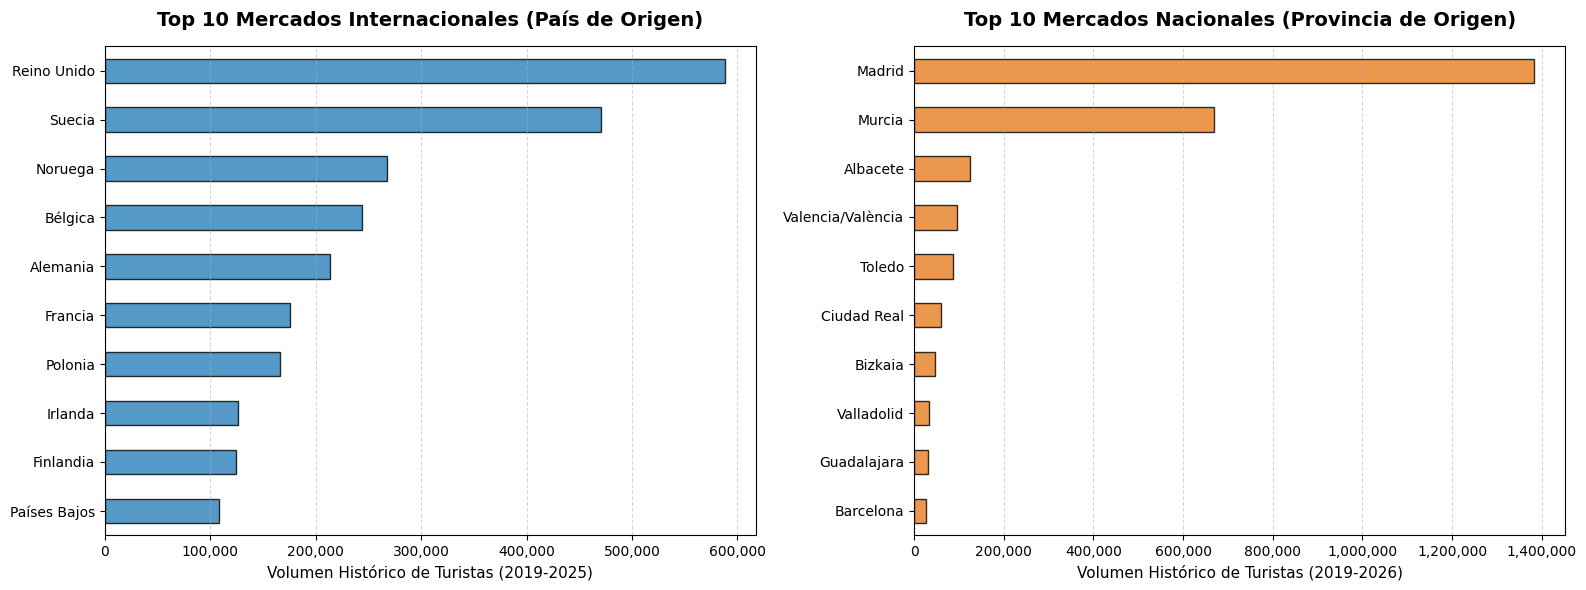

In [ ]:
# ==============================================================================
# ANÁLISIS DE ORÍGENES (MERCADOS EMISORES TOP 10)
# ==============================================================================
import matplotlib.pyplot as plt

# Filtramos agregaciones del INE
df_paises = df_receptor[~df_receptor['pais_orig'].str.contains('Total', case=False, na=False)]

# Seleccionamos el Top 10
top_paises = df_paises.groupby('pais_orig')['turistas'].sum().nlargest(10).sort_values(ascending=True)
top_provincias = df_interno.groupby('prov_orig')['turistas'].sum().nlargest(10).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Turismo Internacional
top_paises.plot(kind='barh', ax=axes[0], color='#2980b9', edgecolor='black', alpha=0.8)
axes[0].set_title('Top 10 Mercados Internacionales (País de Origen)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Volumen Histórico de Turistas (2019-2025)', fontsize=11)
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Gráfica 2: Turismo Nacional
top_provincias.plot(kind='barh', ax=axes[1], color='#e67e22', edgecolor='black', alpha=0.8)
axes[1].set_title('Top 10 Mercados Nacionales (Provincia de Origen)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Volumen Histórico de Turistas (2019-2026)', fontsize=11)
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Al visualizar los mercados emisores, el Reino Unido y los países nórdicos (Suecia, Noruega) dominan claramente, alineado con un perfil de residente estacional. A nivel nacional, la procedencia está liderada por Madrid indiscutiblemente, seguida del turismo de proximidad (Murcia, Albacete, Valencia).

Una vez comprendido el origen, pasamos a analizar el cuándo. Para graficar la serie temporal correctamente, debemos solucionar el problema jerárquico detectado en el EDA. Si aplicáramos una función de suma matemática directa sobre todos los registros mensuales, estaríamos duplicando e incluso triplicando a las mismas personas (sumando los suecos, más el total de Europa, más el total mundial simultáneamente).

Para evitar este conteo doble, diseñamos una función de preparación temporal que filtra explícitamente la fila `Total` en el turismo receptor y emisor (utilizando el dato ya agregado por el INE), mientras que suma los registros individuales en el turismo interno (que carece de filas de totales).

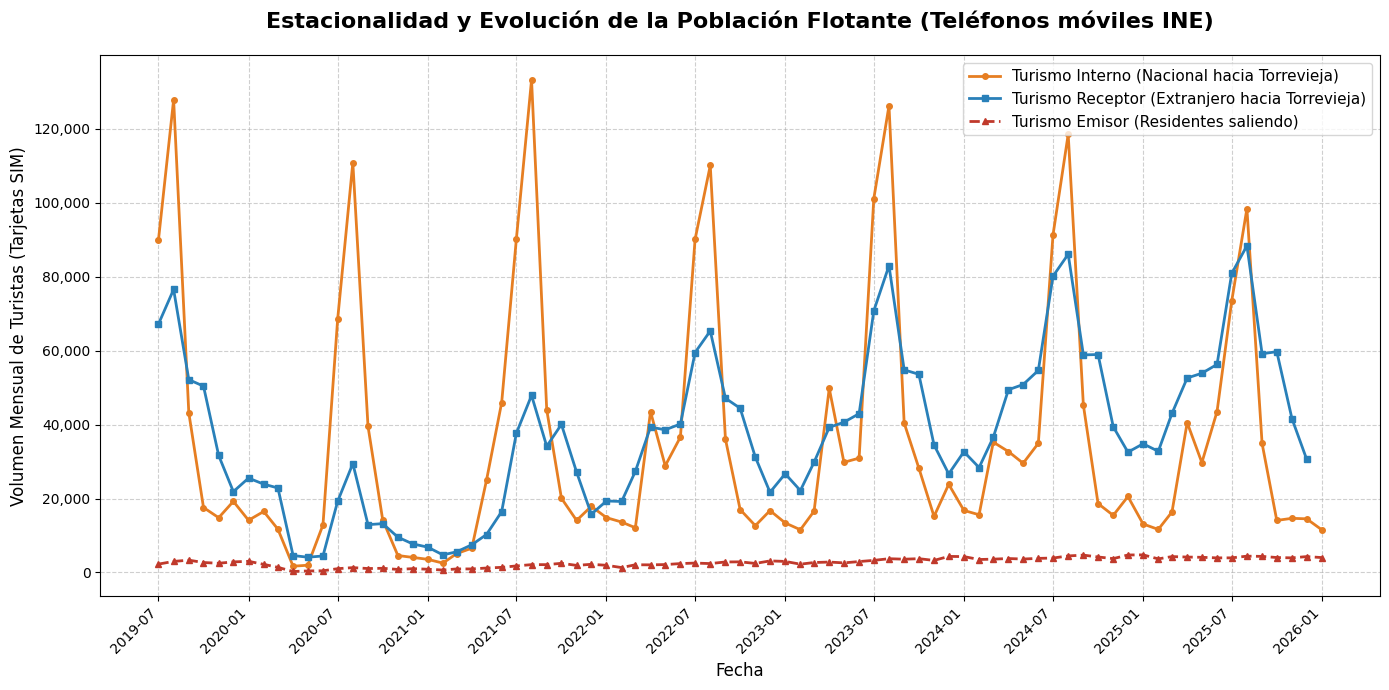

In [ ]:
# ==============================================================================
# PREPARACIÓN TEMPORAL (PREVENCIÓN DE CONTEO DOBLE) Y ESTACIONALIDAD
# ==============================================================================
import matplotlib.dates as mdates

def preparar_serie_temporal(df, nombre_dataset):
    df_temp = df.copy()
    
    # Aplicamos la lógica de prevención de duplicados
    if 'pais_orig' in df_temp.columns:
        df_temp = df_temp[df_temp['pais_orig'] == 'Total']
    elif 'destino' in df_temp.columns:
        df_temp = df_temp[df_temp['destino'] == 'Total']
        
    # Agrupamos por fecha y sumamos
    df_agrupado = df_temp.groupby('fecha')['turistas'].sum().reset_index()
    df_agrupado.rename(columns={'turistas': 'total_turistas'}, inplace=True)
    
    return df_agrupado

# Preparamos las tres series temporales
df_receptor_agg = preparar_serie_temporal(df_receptor, "Receptor")
df_interno_agg = preparar_serie_temporal(df_interno, "Interno")
df_emisor_agg = preparar_serie_temporal(df_emisor, "Emisor")

# ==============================================================================
# GRÁFICA DE LA SERIE TEMPORAL
# ==============================================================================
plt.figure(figsize=(14, 7))

plt.plot(df_interno_agg['fecha'], df_interno_agg['total_turistas'], 
         label='Turismo Interno (Nacional hacia Torrevieja)', color='#e67e22', linewidth=2, marker='o', markersize=4)

plt.plot(df_receptor_agg['fecha'], df_receptor_agg['total_turistas'], 
         label='Turismo Receptor (Extranjero hacia Torrevieja)', color='#2980b9', linewidth=2, marker='s', markersize=4)

plt.plot(df_emisor_agg['fecha'], df_emisor_agg['total_turistas'], 
         label='Turismo Emisor (Residentes saliendo)', color='#c0392b', linewidth=2, linestyle='--', marker='^', markersize=4)

plt.title('Estacionalidad y Evolución de la Población Flotante (Teléfonos móviles INE)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Volumen Mensual de Turistas (Tarjetas SIM)', fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

Esta gráfica nos confirma visualmente el comportamiento demográfico fluctuante de Torrevieja:

* El turismo interno (nacional) es el responsable de los grandes picos de saturación del municipio. Observamos cómo las cifras aumentan exponencialmente durante los meses de julio y agosto, superando los 120.000 turistas.
* A diferencia del mercado nacional, el turismo receptor (extranjero) se mantiene mucho más constante durante la temporada baja, confirmando la presencia del turista residencial de invierno. Además, notamos una clara tendencia al alza en los años pospandemia (2023-2025), llegando a igualar e incluso superar los picos del turismo nacional en ciertos meses.
* El volumen del turismo emisor (residentes empadronados que abandonan Torrevieja temporalmente) es estadísticamente marginal en comparación con las entradas de turistas registradas.
* A partir de marzo de 2020, a causa de la pandemia, se reflejan los mínimos absolutos de movilidad, lo que nos sirve como validación empírica de la sensibilidad de estos datos.

#### C. CÁLCULO DE LA POBLACIÓN REAL

Habiendo validado nuestras dos grandes piezas del puzzle (la Población Residente estimada por la PEGV y la Población Flotante medida por el INE), procedemos al paso definitivo del Reto 1: calcular la **Población Efectiva** (la demanda demográfica real).

Cómo hemos visto, tanto la Población Residente estimada por la PEGV como la Población Flotante medida por el INE son fuentes fiables de información. Por tanto, haciendo uso de estas, ya podemos calcular la Población Real de Torrevieja; para ello definimos la siguiente fórmula matemática:

`Población Efectiva = Población Empadronada (PEGV) + Turismo Receptor + Turismo Interno - Turismo Emisor`

A nivel técnico, cruzamos la tabla de movilidad mensual con el dato estático anual de la PEGV, propagando la población base de cada año a todos sus meses correspondientes.

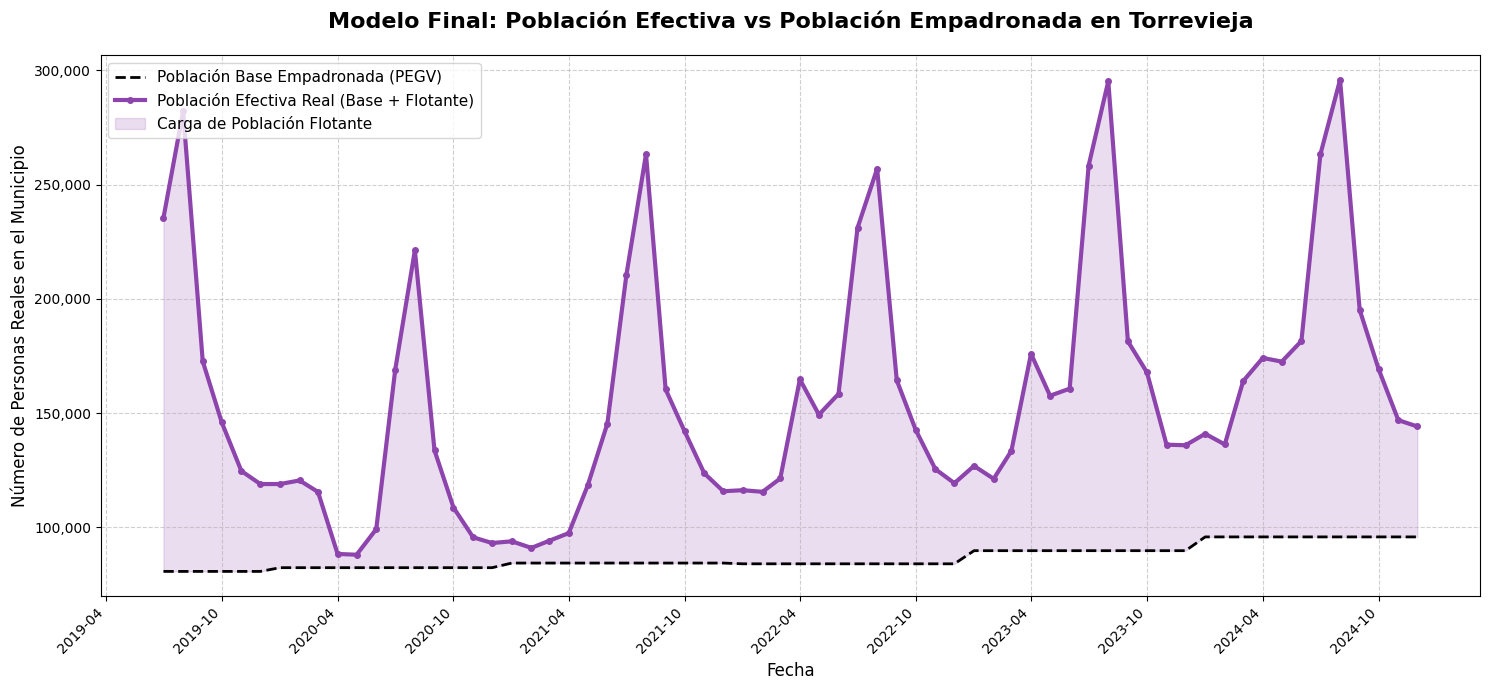

In [ ]:
# ==============================================================================
# INTEGRACIÓN FINAL: CÁLCULO DE LA POBLACIÓN EFECTIVA
# ==============================================================================
import numpy as np

# Cargamos la población base unificada (usamos la PEGV filtrada a 1 de enero)
# Nota: df_unificado proviene de las celdas ejecutadas en el apartado de la PEGV
df_base = df_unificado[df_unificado['Periodo'].str.contains('1 de enero', case=False, na=False)].copy()
df_base['año'] = df_base['Periodo'].str.extract(r'(\d{4})').astype(int)
df_base_total = df_base[df_base['Sexo'] == 'Total'][['año', 'Valor']].rename(columns={'Valor': 'poblacion_base'})

# Consolidamos la movilidad en un solo DataFrame temporal partiendo del turismo interno
df_efectiva = df_interno_agg[['fecha', 'total_turistas']].rename(columns={'total_turistas': 'turismo_interno'})

# Añadimos el turismo receptor y emisor
df_efectiva = pd.merge(df_efectiva, df_receptor_agg[['fecha', 'total_turistas']], on='fecha', how='left')
df_efectiva = df_efectiva.rename(columns={'total_turistas': 'turismo_receptor'})

df_efectiva = pd.merge(df_efectiva, df_emisor_agg[['fecha', 'total_turistas']], on='fecha', how='left')
df_efectiva = df_efectiva.rename(columns={'total_turistas': 'turismo_emisor'})

# Rellenamos posibles nulos con 0 
df_efectiva = df_efectiva.fillna(0)

# Extraemos el año para poder cruzar con el padrón base
df_efectiva['año'] = df_efectiva['fecha'].dt.year

# Cruzamos con la población base de la PEGV
df_efectiva = pd.merge(df_efectiva, df_base_total, on='año', how='inner')

# Aplicamos la fórmula de la Población Efectiva
df_efectiva['poblacion_efectiva'] = (df_efectiva['poblacion_base'] + 
                                     df_efectiva['turismo_interno'] + 
                                     df_efectiva['turismo_receptor'] - 
                                     df_efectiva['turismo_emisor'])

# Guardamos el modelo final
ruta_efectiva = os.path.join(RUTA_SALIDA, 'poblacion_efectiva_torrevieja.csv')
df_efectiva.to_csv(ruta_efectiva, index=False, sep=';', encoding='utf-8-sig')

# ==============================================================================
# VISUALIZACIÓN DEL MODELO DE POBLACIÓN EFECTIVA
# ==============================================================================
plt.figure(figsize=(15, 7))

# Trazamos la población base (línea estática anual)
plt.plot(df_efectiva['fecha'], df_efectiva['poblacion_base'], 
         label='Población Base Empadronada (PEGV)', color='black', linewidth=2, linestyle='--')

# Trazamos la población efectiva real
plt.plot(df_efectiva['fecha'], df_efectiva['poblacion_efectiva'], 
         label='Población Efectiva Real (Base + Flotante)', color='#8e44ad', linewidth=3, marker='o', markersize=4)

# Rellenamos el área entre ambas para evidenciar la carga flotante
plt.fill_between(df_efectiva['fecha'], df_efectiva['poblacion_base'], df_efectiva['poblacion_efectiva'], 
                 color='#9b59b6', alpha=0.2, label='Carga de Población Flotante')

plt.title('Modelo Final: Población Efectiva vs Población Empadronada en Torrevieja', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Personas Reales en el Municipio', fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

Observando esta gráfica, podemos demostrar que la población empadronada (la línea negra) es un indicador completamente insuficiente para gestionar un destino turístico residencial como Torrevieja.

Mientras que los registros oficiales asignan al municipio una carga estática de entre 80.000 y 90.000 habitantes, la realidad demográfica (línea morada) nos muestra que:
1. En temporada baja, la ciudad soporta una población real que rara vez baja de las 110.000 personas.
2. En temporada alta (julio y agosto), la población real se dispara, superando las 250.000 e incluso 300.000 personas consumiendo recursos, agua, seguridad y servicios públicos de forma simultánea.

## 3. VALIDACIÓN MEDIANTE VARIABLES PROXY

Habiendo calculado la Población Efectiva mediante los dispositivos móviles, alcanzamos una conclusión impactante: Torrevieja soporta picos que rozan las 300.000 personas. Para dotar de rigor científico a este hallazgo y descartar posibles sesgos de la telefonía móvil, procedemos a realizar un proceso de **triangulación de datos**. 

Validamos nuestra estimación cruzando el modelo con variables *proxy*; es decir, rastros indirectos físicos, de consumo y de comportamiento que deja la presencia humana en el municipio. Para abordar este análisis integral, hemos intentado recopilar un amplio abanico de fuentes oficiales divididas en tres grandes dimensiones:

**1. Dimensión Urbanística y Energética (Capacidad de acogida)**
* **Censos de Población y Viviendas (INE):** Datos sobre el tipo de viviendas (principales, secundarias, vacías) correspondientes a las oleadas de 2001 ([`tipo_vivienda_2001_ine.csv`](https://www.ine.es/censo/es/listatablas.jsp?table=tablas/provincial/03/V1.html)), 2011 ([`tipo_vivienda_2011_ine.csv`](https://www.ine.es/jaxi/Tabla.htm?path=/t20/e244/viviendas/p06/l0/&file=11mun03.px&L=0)) y 2021 ([`tipo_vivienda_2021_ine.csv`](https://www.ine.es/censo/es/listatablas.jsp?table=tablas/provincial/03/V1.html)).
* **Consumo Eléctrico (INE):** Estadística experimental del INE de 2021 ([`viviendas_por_consumo_eléctrico_2021_ine.csv`](https://www.ine.es/jaxi/Tabla.htm?tpx=59531&L=0)) que cruza los contadores eléctricos con el Catastro para determinar el uso real de las viviendas. 

**2. Dimensión de Carga Biológica y Suministros** (No hemos conseguido encontrar y/o obtener esta información)
* **Residuos Sólidos Urbanos (RSU)** 
* **Consumo de Agua Potable** 

**3. Dimensión de Alojamiento Turístico Reglado**
* **Ocupación Hotelera y Apartamentos (INE):** Encuestas de ocupación y pernoctaciones para cuantificar el volumen de turistas alojados en el mercado reglado ([`encuesta_oupacion_hotelera.csv`](https://www.ine.es/jaxiT3/Tabla.htm?t=2078&L=0), [`encuesta_ocupacion_apartamentos_turisticos.csv`](https://www.ine.es/jaxiT3/Tabla.htm?t=2082&L=0), [`estimacion_alojamientos_turisticos_noches_ocupados.csv`]( https://www.ine.es/jaxiT3/Tabla.htm?t=48424&L=0), [`estimacion_pernocataciones.csv`](https://www.ine.es/jaxiT3/Tabla.htm?t=48426&L=0)).


### 3.1. Dimensión Urbanística: Evolución del Parque Inmobiliario

El primer paso para validar nuestro modelo es realizar una comprobación física de la capacidad de acogida. Para ello, analizamos la evolución del parque de viviendas integrando los datos de los tres últimos censos (2001, 2011, 2021). Dado que la información proviene de tres décadas distintas, las metodologías y formatos de exportación del INE han variado considerablemente. Por ello, el primer paso consiste en cargar los datos crudos (*raw data*) y realizar un Análisis Exploratorio (EDA) para comprender la estructura individual de cada archivo.

In [ ]:
# ==============================================================================
# IMPORTACIÓN Y EXPLORACIÓN INICIAL: CENSOS DE VIVIENDAS (2001, 2011, 2021)
# ==============================================================================
import pandas as pd
import os

# Definimos la ruta exacta proporcionada
RUTA_VIVIENDAS = (
    base_dir.parent / "DATASETS" / "RETO 1" /
    "DATASETS ORIGINALES" / "Tipo_vivienda")

# Diseñamos una función de carga adaptativa. 
# El parámetro sep=None y engine='python' permite a Pandas "adivinar" si el archivo usa comas o punto y coma.
def cargar_csv_adaptativo(nombre_archivo):
    ruta_completa = os.path.join(RUTA_VIVIENDAS, nombre_archivo)
    try:
        # Intentamos con codificación moderna
        df = pd.read_csv(ruta_completa, sep=None, engine='python', encoding='utf-8-sig')
    except UnicodeDecodeError:
        # Si falla por tildes/eñes antiguas, pasamos a codificación europea occidental
        df = pd.read_csv(ruta_completa, sep=None, engine='python', encoding='latin1')
    return df

# Cargamos los tres archivos
df_viv_2001 = cargar_csv_adaptativo("tipo_vivienda_2001_ine.csv")
df_viv_2011 = cargar_csv_adaptativo("tipo_vivienda_2011_ine.csv")
df_viv_2021 = cargar_csv_adaptativo("tipo_vivienda_2021_ine.csv")

# Función auxiliar para imprimir la estructura y detectar anomalías
def explorar_censo(df, anio):
    print(f"\n{'='*60}")
    print(f" ANÁLISIS EXPLORATORIO: CENSO DE VIVIENDAS {anio}")
    print(f"{'='*60}")
    print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas")
    print("Columnas detectadas:")
    for col in df.columns:
        print(f"  - {col}")
    print("\nPrimeras filas:")
    display(df.head(3))

# Ejecutamos la exploración inicial
explorar_censo(df_viv_2001, 2001)
explorar_censo(df_viv_2011, 2011)
explorar_censo(df_viv_2021, 2021)


 ANÁLISIS EXPLORATORIO: CENSO DE VIVIENDAS 2001
Dimensiones: 1 filas y 6 columnas
Columnas detectadas:
  - Municipio
  - Anyo_Censo
  - Total_Viviendas
  - Viviendas_Principales
  - Viviendas_Secundarias
  - Viviendas_Vacias

Primeras filas:


,Municipio,Anyo_Censo,Total_Viviendas,Viviendas_Principales,Viviendas_Secundarias,Viviendas_Vacias
0,Torrevieja,2001,102363,21565,61745,18898



 ANÁLISIS EXPLORATORIO: CENSO DE VIVIENDAS 2011
Dimensiones: 3 filas y 4 columnas
Columnas detectadas:
  - Tipo de vivienda
  - Municipios (con más de 50.000 habitantes o capitales)
  - Año de construcción (agregado) del edificio
  - Total

Primeras filas:


,Tipo de vivienda,Municipios (con más de 50.000 habitantes o capitales),Año de construcción (agregado) del edificio,Total
0,2.1 Total viviendas principales,03133 Torrevieja,Total,39.855
1,2.21 Viviendas secundarias,03133 Torrevieja,Total,62.585
2,2.22 Viviendas vacias,03133 Torrevieja,Total,19.887



 ANÁLISIS EXPLORATORIO: CENSO DE VIVIENDAS 2021
Dimensiones: 3 filas y 3 columnas
Columnas detectadas:
  - Municipios (con más de 50.000 habitantes) y capitales de provincia
  - Tipo de vivienda (principal o no)
  - Total

Primeras filas:


,Municipios (con más de 50.000 habitantes) y capitales de provincia,Tipo de vivienda (principal o no),Total
0,03133 Torrevieja,Total,122.736
1,03133 Torrevieja,Vivienda principal,36.829
2,03133 Torrevieja,Vivienda no principal,85.907


* El archivo del año 2001 utiliza la coma (`,`) como separador, lo que causaba que Python lo interpretara todo como una sola columna. Los `csv` siguientes utilizan el punto y coma (`;`).
* El censo de 2001 presenta cada tipo de casa en una columna, 2011 agrupa las viviendas en tres grandes grupos (`Viviendas vacías`, `Total viviendas principales` y `Viviendas secundarias`) y 2021 las agrupa en dos grupos (`Vivienda principal`, `Vivienda no principal`)
* 
Para resolver procesamos cada archivo de forma individual; comenzando con la corrección y transformación del censo de 2001.

In [ ]:
# ==============================================================================
# HOMOGENEIZACIÓN INDIVIDUAL: CENSO 2001
# ==============================================================================
# Forzamos explícitamente el uso de la coma como separador y probamos codificaciones
try:
    df_2001_raw = pd.read_csv(os.path.join(RUTA_VIVIENDAS, "tipo_vivienda_2001_ine.csv"), sep=',', encoding='utf-8-sig')
except UnicodeDecodeError:
    df_2001_raw = pd.read_csv(os.path.join(RUTA_VIVIENDAS, "tipo_vivienda_2001_ine.csv"), sep=',', encoding='latin1')

# Transformamos de formato ancho a las dos categorías unificadas (sumando secundarias y vacías)
hist_2001 = pd.DataFrame({
    'año_censo': [2001, 2001],
    'tipo_vivienda': ['Vivienda principal', 'Vivienda no principal'],
    'total_viviendas': [
        df_2001_raw['Viviendas_Principales'].values[0], 
        df_2001_raw['Viviendas_Secundarias'].values[0] + df_2001_raw['Viviendas_Vacias'].values[0]
    ]
})

print("Censo de 2001 procesado con éxito.")
display(hist_2001)

Censo de 2001 procesado con éxito.


,año_censo,tipo_vivienda,total_viviendas
0,2001,Vivienda principal,21565
1,2001,Vivienda no principal,80643


A continuación, procesamos el censo de 2011. En este caso, el reto principal es limpiar el formato de los números (que incluyen puntos de millar, interpretados como texto por el sistema) y reclasificar las categorías antiguas para que coincidan con la nueva normativa del INE de 2021 ("Vivienda no principal").

In [ ]:
# ==============================================================================
# HOMOGENEIZACIÓN INDIVIDUAL: CENSO 2011
# ==============================================================================
# Este archivo utiliza punto y coma
try:
    df_2011_raw = pd.read_csv(os.path.join(RUTA_VIVIENDAS, "tipo_vivienda_2011_ine.csv"), sep=';', encoding='utf-8-sig')
except UnicodeDecodeError:
    df_2011_raw = pd.read_csv(os.path.join(RUTA_VIVIENDAS, "tipo_vivienda_2011_ine.csv"), sep=';', encoding='latin1')
    
# Filtramos para Torrevieja y hacemos una copia limpia
df_2011_torre = df_2011_raw[df_2011_raw['Municipios (con más de 50.000 habitantes o capitales)'].str.contains('Torrevieja', na=False, case=False)].copy()

# Eliminamos los puntos de los miles y convertimos a número entero
df_2011_torre['Total'] = df_2011_torre['Total'].astype(str).str.replace('.', '', regex=False).astype(int)

# Reclasificamos al estándar actual
df_2011_torre['tipo_vivienda'] = df_2011_torre['Tipo de vivienda'].apply(
    lambda x: 'Vivienda principal' if 'principal' in str(x).lower() else 'Vivienda no principal'
)

# Agrupamos sumando los totales
hist_2011 = df_2011_torre.groupby('tipo_vivienda')['Total'].sum().reset_index()
hist_2011['año_censo'] = 2011
hist_2011.rename(columns={'Total': 'total_viviendas'}, inplace=True)

print("Censo de 2011 procesado con éxito.")
display(hist_2011)

Censo de 2011 procesado con éxito.


,tipo_vivienda,total_viviendas,año_censo
0,Vivienda no principal,82472,2011
1,Vivienda principal,39855,2011


Finalmente, procesamos el censo de 2021 Tras limpiar sus valores numéricos, procedemos a concatenar las tres tablas históricas en una sola estructura y graficamos la evolución temporal de la capacidad de alojamiento.

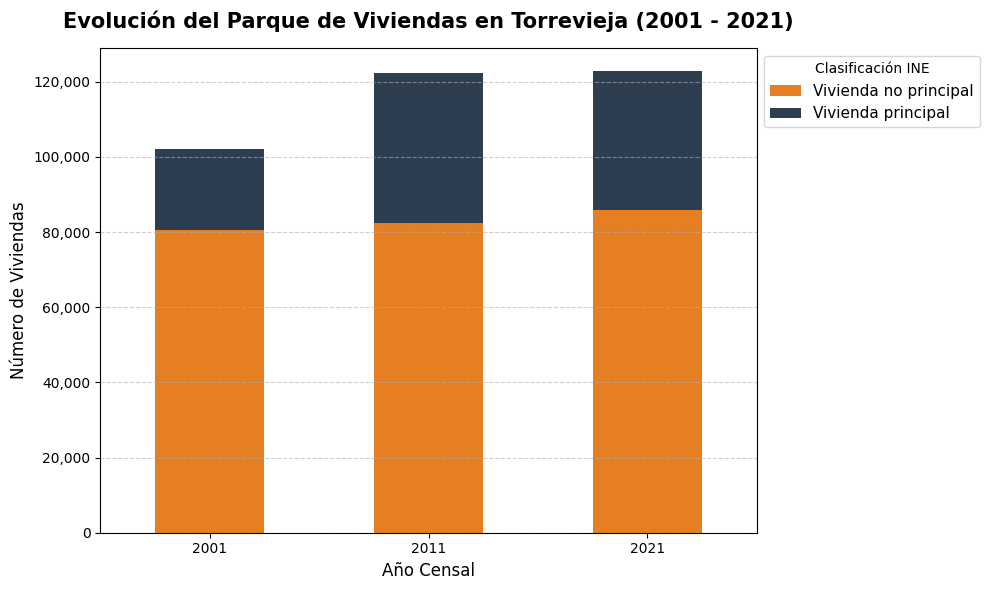

In [ ]:
# ==============================================================================
# HOMOGENEIZACIÓN CENSO 2021, INTEGRACIÓN FINAL Y VISUALIZACIÓN
# ==============================================================================
# Cargamos el censo más reciente aplicando la misma robustez de codificación
try:
    df_2021_raw = pd.read_csv(os.path.join(RUTA_VIVIENDAS, "tipo_vivienda_2021_ine.csv"), sep=';', encoding='utf-8-sig')
except UnicodeDecodeError:
    df_2021_raw = pd.read_csv(os.path.join(RUTA_VIVIENDAS, "tipo_vivienda_2021_ine.csv"), sep=';', encoding='latin1')

# Filtramos Torrevieja
df_2021_torre = df_2021_raw[df_2021_raw['Municipios (con más de 50.000 habitantes) y capitales de provincia'].str.contains('Torrevieja', na=False, case=False)].copy()

# Limpiamos los miles y convertimos a entero
df_2021_torre['Total'] = df_2021_torre['Total'].astype(str).str.replace('.', '', regex=False).astype(int)

# Normalizamos las columnas
df_2021_torre['tipo_vivienda'] = df_2021_torre['Tipo de vivienda (principal o no)'].apply(
    lambda x: 'Vivienda principal' if 'principal' in str(x).lower() and 'no' not in str(x).lower() 
    else ('Vivienda no principal' if 'no principal' in str(x).lower() else 'Descartar')
)

# Filtramos la fila de "Total" general que crea el INE y estructuramos
hist_2021 = df_2021_torre[df_2021_torre['tipo_vivienda'] != 'Descartar'].groupby('tipo_vivienda')['Total'].sum().reset_index()
hist_2021['año_censo'] = 2021
hist_2021.rename(columns={'Total': 'total_viviendas'}, inplace=True)

# ------------------------------------------------------------------------------
# CONCATENACIÓN Y GRÁFICA
# ------------------------------------------------------------------------------
# Unificamos la serie histórica
df_evolucion_viviendas = pd.concat([hist_2001, hist_2011, hist_2021], ignore_index=True)

# Pivotamos la tabla para crear la gráfica de barras apiladas
df_pivot_viviendas = df_evolucion_viviendas.pivot(index='año_censo', columns='tipo_vivienda', values='total_viviendas').fillna(0)

# Configuramos la visualización
colores = {'Vivienda principal': '#2c3e50', 'Vivienda no principal': '#e67e22'}
ax = df_pivot_viviendas.plot(kind='bar', stacked=True, figsize=(10, 6), color=[colores.get(x, '#333333') for x in df_pivot_viviendas.columns])

plt.title('Evolución del Parque de Viviendas en Torrevieja (2001 - 2021)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Año Censal', fontsize=12)
plt.ylabel('Número de Viviendas', fontsize=12)

# Formateamos el eje Y con separador de miles
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=0)

plt.legend(title='Clasificación INE', fontsize=11, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

Actualmente, Torrevieja posee más de 122.000 viviendas en total, de las cuales la inmensa mayoría (cerca de 86.000) no son viviendas principales. 

Este volumen masivo de segundas residencias justifica de manera empírica que la ciudad sea plenamente capaz de alojar y dar soporte a picos de población real de 300.000 personas durante el mes de agosto, sin llegar a colapsar el mercado de alojamientos turísticos. 

### 3.2. Consumo Eléctrico Experimental (2021)

En el apartado anterior demostramos que Torrevieja posee la infraestructura física necesaria para albergar un crecimiento demográfico masivo, contando con casi 86.000 viviendas clasificadas como "no principales" (secundarias o vacías). 

Sin embargo, la mera existencia del inmueble no garantiza que esté habitado. Para validar si este inmenso parque inmobiliario estacional se activa en verano y da soporte a los picos de población flotante, recurrimos a una estadística experimental del INE: el **Consumo Eléctrico**. 

Esta fuente cruza los contadores eléctricos con la base de datos del Catastro para determinar objetivamente el uso real de las viviendas en función de su gasto energético anual. Vamos a comenzar con un Análisis Exploratorio de Datos (EDA) para comprender la estructura del archivo antes de procesarlo.

In [ ]:
# ==============================================================================
# IMPORTACIÓN Y EXPLORACIÓN INICIAL: CONSUMO ELÉCTRICO 2021
# ==============================================================================
import pandas as pd
import os

# Ajusta esta ruta si guardaste el CSV de la luz en una subcarpeta distinta. 
# Por defecto asumimos que está en la carpeta de DATASETS ORIGINALES
RUTA_ELECTRICIDAD = ruta_base / "DATASETS ORIGINALES"
# Archivo objetivo
archivo_elec = "viviendas_por_consumo_eléctrico_2021_ine.csv"

# Utilizamos nuestra función robusta por si el archivo contiene tildes (como en "eléctrico")
try:
    df_elec_raw = pd.read_csv(os.path.join(RUTA_ELECTRICIDAD, archivo_elec), sep=';', encoding='utf-8-sig')
except UnicodeDecodeError:
    df_elec_raw = pd.read_csv(os.path.join(RUTA_ELECTRICIDAD, archivo_elec), sep=';', encoding='latin1')
except FileNotFoundError:
    # Si no lo encuentra, probamos en la carpeta de viviendas por si lo guardaste ahí
    df_elec_raw = pd.read_csv(os.path.join(RUTA_VIVIENDAS, archivo_elec), sep=';', encoding='latin1')

# Buscamos la columna de municipio (el INE suele llamarla "Municipios" o similar)
col_mun_elec = [col for col in df_elec_raw.columns if 'municipio' in col.lower()][0]

# Filtramos para aislar los datos de Torrevieja
df_elec_torre = df_elec_raw[df_elec_raw[col_mun_elec].str.contains('Torrevieja', case=False, na=False)].copy()

print(f"\n{'='*60}")
print(f" ANÁLISIS EXPLORATORIO: CONSUMO ELÉCTRICO (TORREVIEJA)")
print(f"{'='*60}")
print(f"Dimensiones: {df_elec_torre.shape[0]} filas y {df_elec_torre.shape[1]} columnas")
print("\nColumnas detectadas:")
for col in df_elec_torre.columns:
    print(f"  - {col}")

print("\nValores únicos en las categorías de consumo:")
col_consumo = [col for col in df_elec_torre.columns if 'consumo' in col.lower()][0]
print(df_elec_torre[col_consumo].unique())

print("\nPrimeras filas:")
display(df_elec_torre.head(5))


 ANÁLISIS EXPLORATORIO: CONSUMO ELÉCTRICO (TORREVIEJA)
Dimensiones: 18 filas y 6 columnas

Columnas detectadas:
  - Total Nacional
  - Comunidades y Ciudades Autónomas
  - Provincias
  - Municipios
  - Consumo eléctrico
  - Total

Valores únicos en las categorías de consumo:
<StringArray>
[                                'Viviendas totales',
                                  'Viviendas vacías',
                             'Mediana consumo anual',
                        'Viviendas con bajo consumo',
                       'Viviendas de uso esporádico',
 'Viviendas de uso esporádico (entre 251 y 500 kwh)',
 'Viviendas de uso esporádico (entre 501 y 750 kwh)',
       'Viviendas con consumo entre 751 y 1.000 kwh',
     'Viviendas con consumo entre 1.001 y 2.000 kwh',
     'Viviendas con consumo entre 2.001 y 3.000 kwh',
     'Viviendas con consumo entre 3.001 y 4.000 kwh',
     'Viviendas con consumo entre 4.001 y 5.000 kwh',
     'Viviendas con consumo entre 5.001 y 6.000 kwh',
     'V

,Total Nacional,Comunidades y Ciudades Autónomas,Provincias,Municipios,Consumo eléctrico,Total
0,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas totales,122.736
1,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas vacías,30.546
2,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Mediana consumo anual,1.425
3,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas con bajo consumo,14.988
4,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas de uso esporádico,23.513


El INE tiene registrados 122.736 contadores en Torrevieja, una cifra idéntica al número total de viviendas del Censo de 2021. 

Sin embargo, las categorías de consumo revelan una realidad muy distinta a la administrativa. Mientras que el padrón sugería que cerca de 86.000 de estas viviendas no eran la residencia principal de nadie, los contadores eléctricos nos indican otra cosa. 

Para interpretar estos datos vamos a dividir los datos en tres macro-categorías analíticas:

1. Deshabitadas (Vacías reales): Contadores con consumo nulo o residual.
2. Uso Estacional / Vacacional: Viviendas que el INE etiqueta explícitamente como `Viviendas con bajo consumo` y `Viviendas de uso esporádico`(típicamente asociadas a segundas residencias de verano o alquileres cortos).
3. Uso Habitual: El resto de las viviendas, cuyo consumo eléctrico continuo a lo largo del año demuestra que están plenamente habitadas, independientemente de quién esté empadronado en ellas.

=== VERDADERO USO DEL PARQUE INMOBILIARIO (SEGÚN CONTADORES) ===


,Categoria,Viviendas,Porcentaje (%)
0,Deshabitadas (Vacías Reales),"30,546",24.9%
1,Uso Estacional / Vacacional,"38,501",31.4%
2,Uso Habitual (Continuo),"53,689",43.7%


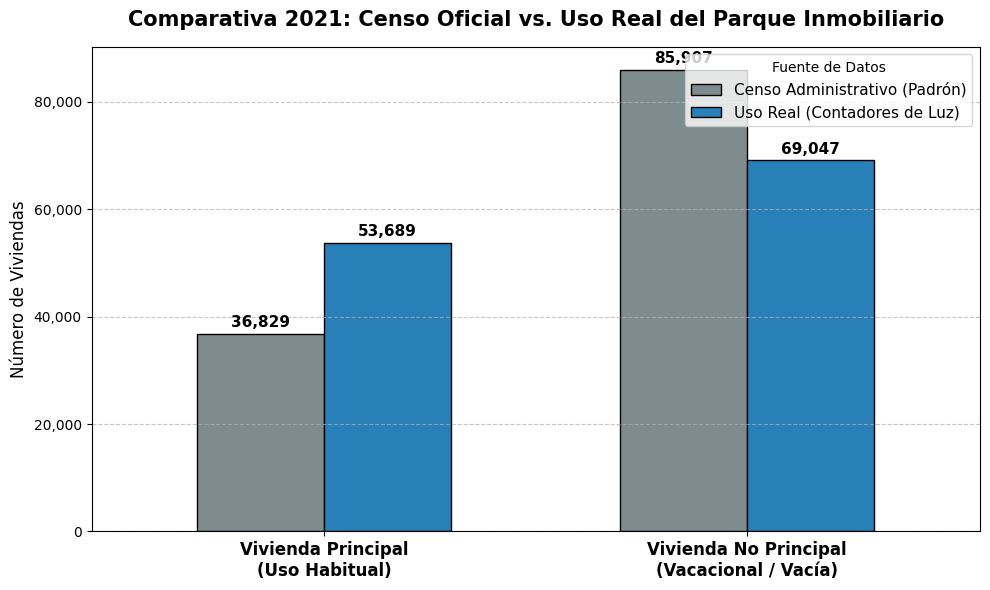

In [ ]:
# ==============================================================================
# PROCESAMIENTO DEL CONSUMO ELÉCTRICO Y AGRUPACIÓN (CORREGIDO)
# ==============================================================================
import matplotlib.pyplot as plt

# 1. Limpieza de formato numérico
df_elec_cln = df_elec_torre.copy()
col_total = [col for col in df_elec_cln.columns if 'total' in col.lower() and col.lower() != 'total nacional'][0]
col_consumo = [col for col in df_elec_cln.columns if 'consumo' in col.lower()][0]

# Eliminamos puntos de millar y forzamos a entero
df_elec_cln[col_total] = df_elec_cln[col_total].astype(str).str.replace('.', '', regex=False).astype(int)

# 2. Extracción de los valores maestros
val_totales = df_elec_cln.loc[df_elec_cln[col_consumo] == 'Viviendas totales', col_total].values[0]
val_vacias = df_elec_cln.loc[df_elec_cln[col_consumo] == 'Viviendas vacías', col_total].values[0]
val_bajo = df_elec_cln.loc[df_elec_cln[col_consumo] == 'Viviendas con bajo consumo', col_total].values[0]
val_esporadico = df_elec_cln.loc[df_elec_cln[col_consumo] == 'Viviendas de uso esporádico', col_total].values[0]

# 3. Agrupación en Macro-categorías
uso_vacacional = val_bajo + val_esporadico
uso_habitual = val_totales - val_vacias - uso_vacacional

# 4. Creación del DataFrame con la columna de Porcentaje
df_consumo_real = pd.DataFrame({
    'Categoria': ['Deshabitadas (Vacías Reales)', 'Uso Estacional / Vacacional', 'Uso Habitual (Continuo)'],
    'Viviendas': [val_vacias, uso_vacacional, uso_habitual]
})

df_consumo_real['Porcentaje (%)'] = (df_consumo_real['Viviendas'] / val_totales * 100).round(1)

print("=== VERDADERO USO DEL PARQUE INMOBILIARIO (SEGÚN CONTADORES) ===")
# Creamos una copia solo para visualizar bonita y evitar el error de jinja2
df_visual = df_consumo_real.copy()
df_visual['Viviendas'] = df_visual['Viviendas'].apply(lambda x: f"{x:,}")
df_visual['Porcentaje (%)'] = df_visual['Porcentaje (%)'].astype(str) + "%"
display(df_visual)

# ==============================================================================
# GRÁFICA COMPARATIVA: CENSO 2021 vs CONSUMO ELÉCTRICO 2021 (AGRUPADO POR TIPO)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Extraemos los datos del Censo 2021 (ya procesados en pasos anteriores)
censo_prin = hist_2021[hist_2021['tipo_vivienda'] == 'Vivienda principal']['total_viviendas'].values[0]
censo_noprin = hist_2021[hist_2021['tipo_vivienda'] == 'Vivienda no principal']['total_viviendas'].values[0]

# 2. Extraemos los datos del Consumo Eléctrico 2021 (calculados en el bloque anterior)
elec_prin = uso_habitual
elec_noprin = val_vacias + uso_vacacional

# 3. Creamos el DataFrame comparativo estructurado por Tipo de Vivienda
df_comparativa = pd.DataFrame({
    'Tipo de Vivienda': ['Vivienda Principal\n(Uso Habitual)', 'Vivienda No Principal\n(Vacacional / Vacía)'],
    'Censo Administrativo (Padrón)': [censo_prin, censo_noprin],
    'Uso Real (Contadores de Luz)': [elec_prin, elec_noprin]
})

# Establecemos el tipo de vivienda como índice para que Pandas agrupe las barras correctamente
df_comparativa.set_index('Tipo de Vivienda', inplace=True)

# 4. Configuración y trazado de la gráfica
colores_comp = ['#7f8c8d', '#2980b9'] # Gris para el Censo (papel), Azul para el Consumo (realidad)
ax = df_comparativa.plot(kind='bar', figsize=(10, 6), color=colores_comp, edgecolor='black', width=0.6)

plt.title('Comparativa 2021: Censo Oficial vs. Uso Real del Parque Inmobiliario', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('', fontsize=12)
plt.ylabel('Número de Viviendas', fontsize=12)

# Ajustes de diseño
plt.xticks(rotation=0, fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.legend(title='Fuente de Datos', fontsize=11, loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadimos los valores exactos encima de cada barra para mostrar claramente la diferencia
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), 
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

En 2021, el Censo administrativo etiquetaba 39.855 como `Vivienda principal`, pero como podemos contrastar con estos nuevos datos, casi 55.000 viviendas son las que podemos considerar de uso habitual debido a su consumo energético. Por tanto, podemos indicar que el Censo administrativo está infracontando el número de viviendas habitadas de manera habitual. 

Por otro lado, cerca de 38.500 viviendas son de uso exclusivamente vacacional y estacional. Si aplicamos un ratio conservador de 3 a 4 personas por vivienda, podemos afirmar que cerca de 120.000 personas pueden habitar estas casas durante la temporada alta, confirmando los datos que hemos obtenido anteriormente de la Población Flotante. 

De esta forma, la dimensión urbanística y energética valida al milímetro las estimaciones de telefonía móvil.

### 3.3. Dimensión de Alojamiento Reglado: Hoteles vs. Modelo Residencial

Lo último de nuestra validación es el análisis del alojamiento turístico tradicional (hoteles y apartamentos turísticos reglados). 

Si nuestro análisis indica que Torrevieja alberga a casi 300.000 personas en temporada alta, debemos verificar qué peso tiene la oferta alojativa oficial en esa cifra. Si el volumen de viajeros en hoteles es significativamente inferior a la población flotante total, habremos confirmado empíricamente que los viajeros se establecen en una segunda residencia o hacen uso del alquiler no reglado.

Comenzamos cargando los datos de las encuestas de ocupación y estimaciones del INE para realizar un análisis exploratorio de su estructura.

In [ ]:
# ==============================================================================
# IMPORTACIÓN, EXPLORACIÓN Y AUDITORÍA: ALOJAMIENTO TURÍSTICO REGLADO
# ==============================================================================
import pandas as pd
from pathlib import Path

# Utilizamos pathlib para generar rutas relativas e independientes del sistema operativo
ruta_alojamientos = ruta_base / "DATASETS ORIGINALES" / "Alojamientos"

# Listado de los cuatro archivos a procesar
archivos_alojamiento = {
    "Hoteles": "encuesta_ocupacion_hotelera.csv",
    "Apartamentos": "encuesta_ocupacion_apartamentos_turisticos.csv",
    "Est. Noches": "estimacion_alojamientos_turisticos_noches_ocupados.csv",
    "Est. Pernoctaciones": "estimacion_pernoctaciones.csv"
}

# Función de carga robusta adaptada a pathlib
def cargar_alojamiento_robusto(nombre_archivo):
    ruta_completa = ruta_alojamientos / nombre_archivo
    
    if not ruta_completa.exists():
        print(f"⚠️ ERROR: El archivo '{nombre_archivo}' no se encuentra en:\n{ruta_alojamientos}")
        return None
        
    try:
        return pd.read_csv(ruta_completa, sep=';', encoding='utf-8-sig')
    except UnicodeDecodeError:
        try:
            return pd.read_csv(ruta_completa, sep=';', encoding='latin1')
        except:
            return pd.read_csv(ruta_completa, sep=None, engine='python', encoding='latin1')

# Diccionario para almacenar los DataFrames temporalmente
dfs_alojamiento = {}

# Cargamos y exploramos cada archivo iterativamente
for etiqueta, nombre in archivos_alojamiento.items():
    df_temp = cargar_alojamiento_robusto(nombre)
    dfs_alojamiento[etiqueta] = df_temp
    
    if df_temp is not None:
        print(f"\n{'='*80}")
        print(f" EDA Y AUDITORÍA: {etiqueta.upper()}")
        print(f"{'='*80}")
        print(f"Dimensiones: {df_temp.shape[0]} filas y {df_temp.shape[1]} columnas\n")
        
        print("=== CONTEO DE VALORES NULOS POR COLUMNA ===")
        print(df_temp.isnull().sum())
        
        print("\n=== ANÁLISIS DE VALORES ÚNICOS POR COLUMNA ===")
        for col in df_temp.columns:
            # OMITIMOS LA COLUMNA TOTAL PORQUE NO APORTA VALOR ANALÍTICO AQUÍ
            if col == 'Total':
                continue
                
            unicos = df_temp[col].dropna().unique()
            cantidad = len(unicos)
            print(f"Columna '{col}': {cantidad} valores únicos.")
            
            # Mostramos los valores. Si son muchísimos (como las fechas), cortamos para no saturar.
            if cantidad <= 40:
                print(f"   Valores: {list(unicos)}")
            else:
                print(f"   Valores (muestra): {list(unicos[:5])} ... (y {cantidad - 5} más)")

        print("\n=== FILAS CON EL TOTAL SIN RELLENAR ===")
        # Buscamos nulos puros, cadenas vacías o el clásico punto '.' del INE
        if 'Total' in df_temp.columns:
            df_vacios = df_temp[df_temp['Total'].isna() | (df_temp['Total'] == '.') | (df_temp['Total'] == '')]
            if df_vacios.empty:
                print("¡Perfecto! No hay filas con el Total vacío.")
            else:
                print(f"Se han encontrado {len(df_vacios)} filas sin datos en la columna 'Total'. Aquí están las 3 primeras:")
                display(df_vacios.head(3))
        else:
            print("No existe la columna 'Total'.")


 EDA Y AUDITORÍA: HOTELES
Dimensiones: 1016 filas y 5 columnas

=== CONTEO DE VALORES NULOS POR COLUMNA ===
Puntos turísticos             0
Viajeros y pernoctaciones     0
Residencia                    0
Periodo                       0
Total                        96
dtype: int64

=== ANÁLISIS DE VALORES ÚNICOS POR COLUMNA ===
Columna 'Puntos turísticos': 1 valores únicos.
   Valores: ['03133 Torrevieja']
Columna 'Viajeros y pernoctaciones': 2 valores únicos.
   Valores: ['Viajero', 'Pernoctaciones']
Columna 'Residencia': 2 valores únicos.
   Valores: ['Residentes en España', 'Residentes en el Extranjero']
Columna 'Periodo': 254 valores únicos.
   Valores (muestra): ['2026M02', '2026M01', '2025M12', '2025M11', '2025M10'] ... (y 249 más)

=== FILAS CON EL TOTAL SIN RELLENAR ===
Se han encontrado 624 filas sin datos en la columna 'Total'. Aquí están las 3 primeras:


,Puntos turísticos,Viajeros y pernoctaciones,Residencia,Periodo,Total
0,03133 Torrevieja,Viajero,Residentes en España,2026M02,.
1,03133 Torrevieja,Viajero,Residentes en España,2026M01,.
2,03133 Torrevieja,Viajero,Residentes en España,2025M12,.



 EDA Y AUDITORÍA: APARTAMENTOS
Dimensiones: 1012 filas y 5 columnas

=== CONTEO DE VALORES NULOS POR COLUMNA ===
Puntos turísticos             0
Viajeros y pernoctaciones     0
Residencia                    0
Periodo                       0
Total                        88
dtype: int64

=== ANÁLISIS DE VALORES ÚNICOS POR COLUMNA ===
Columna 'Puntos turísticos': 1 valores únicos.
   Valores: ['03133 Torrevieja']
Columna 'Viajeros y pernoctaciones': 2 valores únicos.
   Valores: ['Viajero', 'Pernoctaciones']
Columna 'Residencia': 2 valores únicos.
   Valores: ['Residentes en España', 'Residentes en el Extranjero']
Columna 'Periodo': 253 valores únicos.
   Valores (muestra): ['2026M01', '2025M12', '2025M11', '2025M10', '2025M09'] ... (y 248 más)

=== FILAS CON EL TOTAL SIN RELLENAR ===
Se han encontrado 172 filas sin datos en la columna 'Total'. Aquí están las 3 primeras:


,Puntos turísticos,Viajeros y pernoctaciones,Residencia,Periodo,Total
13,03133 Torrevieja,Viajero,Residentes en España,2024M12,.
51,03133 Torrevieja,Viajero,Residentes en España,2021M10,.
56,03133 Torrevieja,Viajero,Residentes en España,2021M05,.



 EDA Y AUDITORÍA: EST. NOCHES
Dimensiones: 837 filas y 5 columnas

=== CONTEO DE VALORES NULOS POR COLUMNA ===
Concepto turístico         0
Puntos turísticos          0
Residencia del viajero     0
Periodo                    0
Total                     27
dtype: int64

=== ANÁLISIS DE VALORES ÚNICOS POR COLUMNA ===
Columna 'Concepto turístico': 3 valores únicos.
   Valores: ['Número de alojamientos turísticos ocupados', 'Número de noches ocupadas', 'Estancia media']
Columna 'Puntos turísticos': 1 valores únicos.
   Valores: ['Torrevieja']
Columna 'Residencia del viajero': 3 valores únicos.
   Valores: ['Total', 'Residentes en España', 'Residentes en el Extranjero']
Columna 'Periodo': 93 valores únicos.
   Valores (muestra): ['2025M09', '2025M08', '2025M07', '2025M06', '2025M05'] ... (y 88 más)

=== FILAS CON EL TOTAL SIN RELLENAR ===
Se han encontrado 27 filas sin datos en la columna 'Total'. Aquí están las 3 primeras:


,Concepto turístico,Puntos turísticos,Residencia del viajero,Periodo,Total
0,Número de alojamientos turísticos ocupados,Torrevieja,Total,2025M09,NaN
1,Número de alojamientos turísticos ocupados,Torrevieja,Total,2025M08,NaN
2,Número de alojamientos turísticos ocupados,Torrevieja,Total,2025M07,NaN



 EDA Y AUDITORÍA: EST. PERNOCTACIONES
Dimensiones: 279 filas y 4 columnas

=== CONTEO DE VALORES NULOS POR COLUMNA ===
Puntos turísticos         0
Residencia del viajero    0
Periodo                   0
Total                     9
dtype: int64

=== ANÁLISIS DE VALORES ÚNICOS POR COLUMNA ===
Columna 'Puntos turísticos': 1 valores únicos.
   Valores: ['Torrevieja']
Columna 'Residencia del viajero': 3 valores únicos.
   Valores: ['Total', 'Residentes en España', 'Residentes en el Extranjero']
Columna 'Periodo': 93 valores únicos.
   Valores (muestra): ['2025M09', '2025M08', '2025M07', '2025M06', '2025M05'] ... (y 88 más)

=== FILAS CON EL TOTAL SIN RELLENAR ===
Se han encontrado 9 filas sin datos en la columna 'Total'. Aquí están las 3 primeras:


,Puntos turísticos,Residencia del viajero,Periodo,Total
0,Torrevieja,Total,2025M09,NaN
1,Torrevieja,Total,2025M08,NaN
2,Torrevieja,Total,2025M07,NaN


Vamos ahora a realizar la extracción del volumen real de turistas alojados en el mercado reglado (Hoteles y Apartamentos Turísticos). Para ello:

1. Filtramos la métrica de `Viajeros` (personas físicas, ignorando las pernoctaciones para evitar contar a la misma persona varias veces).
2. Sumamos los turistas nacionales y extranjeros para obtener el volumen mensual total.
3. Limpiamos la sintaxis del INE, gestionando los valores ausentes (marcados con un `.`) y eliminando los separadores de miles.
4. Transformamos la columna de periodo (`YYYYM0M`) a formato fecha (Datetime) para generar una serie temporal histórica.

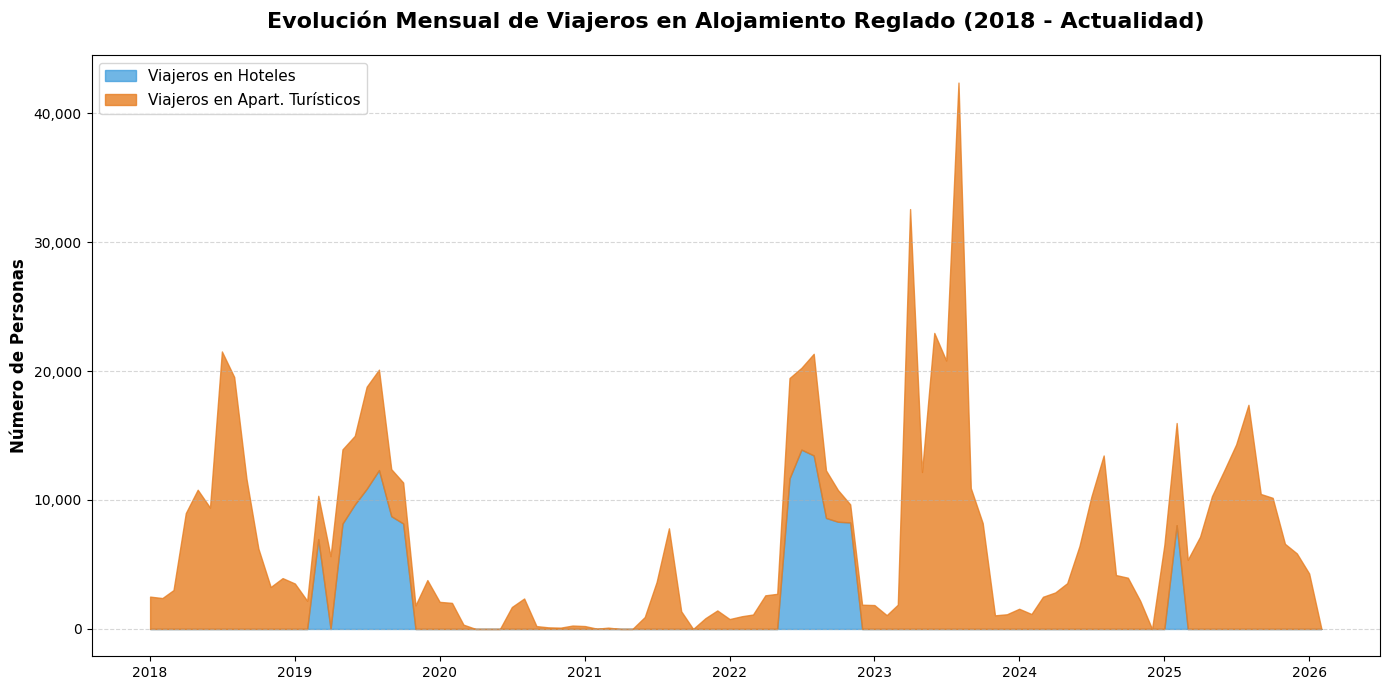

In [ ]:
# ==============================================================================
# LIMPIEZA Y UNIFICACIÓN DE VIAJEROS (HOTELES + APARTAMENTOS)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

def procesar_viajeros(df, nombre_alojamiento):
    # Hacemos una copia para no alterar el original
    df_cln = df.copy()
    
    # 1. Filtramos solo los "Viajeros"
    df_cln = df_cln[df_cln['Viajeros y pernoctaciones'] == 'Viajero'].copy()
    
    # 2. Limpieza del campo Total (Gestión del punto solitario y miles)
    df_cln['Total'] = df_cln['Total'].astype(str).str.strip()
    df_cln['Total'] = df_cln['Total'].apply(lambda x: np.nan if x == '.' or x == '' else x)
    df_cln['Total'] = df_cln['Total'].str.replace('.', '', regex=False) # Quitamos puntos de miles
    df_cln['Total'] = pd.to_numeric(df_cln['Total'], errors='coerce').fillna(0)
    
    # 3. Conversión de fecha (De '2024M08' a '2024-08-01')
    df_cln['Fecha'] = pd.to_datetime(df_cln['Periodo'].str.replace('M', '-') + '-01')
    
    # 4. Agrupamos por fecha sumando residentes españoles y extranjeros
    df_agrupado = df_cln.groupby('Fecha')['Total'].sum().reset_index()
    df_agrupado['Tipo'] = nombre_alojamiento
    
    return df_agrupado

# Extraemos y limpiamos las dos fuentes principales
df_hoteles = procesar_viajeros(dfs_alojamiento['Hoteles'], 'Hoteles')
df_apartamentos = procesar_viajeros(dfs_alojamiento['Apartamentos'], 'Apartamentos Turísticos')

# Unimos ambos datasets
df_alojamiento_reglado = pd.concat([df_hoteles, df_apartamentos], ignore_index=True)

# Pivotamos para tener una columna de Hoteles y otra de Apartamentos por cada mes
df_evolucion = df_alojamiento_reglado.pivot(index='Fecha', columns='Tipo', values='Total').fillna(0)

# Sumamos el total de personas en alojamiento reglado
df_evolucion['Total_Reglado'] = df_evolucion['Hoteles'] + df_evolucion['Apartamentos Turísticos']

# Filtramos desde 2018 para tener una gráfica clara y moderna
df_grafica = df_evolucion[df_evolucion.index >= '2018-01-01']

# ==============================================================================
# GRÁFICA FINAL: EVOLUCIÓN DEL TURISMO REGLADO 
# ==============================================================================
plt.figure(figsize=(14, 7))

# Pintamos el área apilada de Hoteles y Apartamentos
plt.fill_between(df_grafica.index, 0, df_grafica['Hoteles'], label='Viajeros en Hoteles', color='#3498db', alpha=0.7)
plt.fill_between(df_grafica.index, df_grafica['Hoteles'], df_grafica['Total_Reglado'], label='Viajeros en Apart. Turísticos', color='#e67e22', alpha=0.8)

# Configuraciones de la gráfica
plt.title('Evolución Mensual de Viajeros en Alojamiento Reglado (2018 - Actualidad)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Número de Personas', fontsize=12, fontweight='bold')
plt.xlabel('', fontsize=12)

# Formateo de los ejes para que salgan con separadores de miles
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.legend(loc='upper left', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Del análisis de la gráfica generada se extraen las siguientes conclusiones clave:

* Mientras que los viajeros alojados en el mercado oficial (hoteles y apartamentos turísticos) alcanzan un tope máximo histórico alrededor de 45.000 personas, la ciudad soporta una carga demográfica de 300.000 habitantes.  Esto demuestra que cerca del 85% de la población estival no utiliza la infraestructura hotelera, lo que confirma que la mayoría de los visitantes pernocta usando las viviendas de uso vacacional identificado anteriormente mediante el consumo eléctrico.
* La gráfica muestra una estacionalidad perfecta. Los picos de verano son extremadamente pronunciados frente a las caidas en invierno, lo que define a Torrevieja como un destino de sol y playa con una dependencia demográfica estacional muy alta.
* La caída de la ocupación a valores mínimos durante el confinamiento y las restricciones posteriores valida la sensibilidad y precisión de los datos del INE utilizados para esta comparativa.

El análisis conjunto de las tres dimensiones analizadas (**Movilidad Móvil, Consumo Energético y Alojamiento Reglado**) permite dar por validada la estimación de la población flotante:
* **Dimensión de Movilidad:** Detecta la presencia de 300.000 personas.
* **Dimensión Urbanística/Energética:** Demuestra que existen alrededor de 85.000 viviendas capaces de albergar a esa masa crítica.
* **Dimensión de Alojamiento Reglado:** Confirma que el alojamiento oficial es minoritario, reforzando la tesis de que Torrevieja es uno de los máximos exponentes del modelo de turismo residencial en el Mediterráneo.